# Skin Cancer MNIST: HAM10000


The Skin Cancer MNIST: HAM10000 dataset contains over 10.000 pictures of skin lesions. Each picture is labeled as one of seven types, including both benign and malignant lesions. Some labels are confirmed with lab tests, while others are checked by doctors. This dataset is useful for training and testing machine learning models to detect and classify skin cancer. It is widely used in research because it is large, diverse, and realistic.

## First steps

### Libraries

In [2]:
import os
import sys
import pickle
import random

import numpy as np
import pandas as pd
from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler
import torch.optim as optim
from torchvision import models, utils
import torchvision.utils as vutils
from torchvision.utils import save_image
from torch.utils.tensorboard import SummaryWriter

from huggingface_hub import hf_hub_download

import kagglehub
from kagglehub import KaggleDatasetAdapter


I0000 00:00:1776265495.764373    1041 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776265496.114224    1041 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776265497.328060    1041 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/haizea_gonzalez/Cuarto/segundoCuatri/ml_avanzado/Advanced-ML-Project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWar

### Load the data

Since we will be working with images and don’t want to overload the repository, we will load the dataset directly from the option provided by [Kaggle](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000).

In [3]:
# Download from Kaggle the latest version
path = kagglehub.dataset_download("kmader/skin-cancer-mnist-ham10000")

# Create the full path to the metadata CSV file
csv_file = os.path.join(path, "HAM10000_metadata.csv")

# Load the metadata into a pandas DataFrame
df = pd.read_csv(csv_file)

# Display the first few rows of the DataFrame to verify it loaded correctly
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


### Data Cleaning

As the dataset is splitted into two folders ('ham10000_images_part_1' and 'ham10000_images_part_2'), we will define the paths to both folders to ensure we can find any image regardless of which part it is in.

In [4]:
part1_path = os.path.join(path, "ham10000_images_part_1")
part2_path = os.path.join(path, "ham10000_images_part_2")

We will create a function that takes an image_id and returns the full path to the corresponding image, automatically checking both folders (ham10000_images_part_1 and ham10000_images_part_2).

In [5]:
def get_image_path(image_id):
    """
    Get the full path of a skin lesion image given its image ID.

    This function searches for the image in both dataset folders
    ('ham10000_images_part_1' and 'ham10000_images_part_2') and
    returns the absolute path once found.

    Parameters
    ----------
    image_id (str): The ID of the image (without the '.jpg' extension), e.g., 'ISIC_0000000'.

    Returns
    -------
    str
        Full path to the image file.

    Notes
    -----
    - If the image does not exist in either folder, the returned path
      will point to a non-existent file. You may want to check
      os.path.exists() before opening the image.
    """


    # Get the image name by appending '.jpg' to the image_id
    img_name = image_id + ".jpg"

    # Check if the image exists in part 1, if not check in part 2
    img_path = os.path.join(part1_path, img_name)
    if not os.path.exists(img_path):
        img_path = os.path.join(part2_path, img_name)

    return img_path

In [6]:
# Apply the function to create a new column 'image_path' in the DataFrame
df['image_path'] = df['image_id'].apply(get_image_path)

#### Null Values

As in any project, it is important to check for null values and decide how to deal with them if needed.

In [7]:
# Get null values
df_nulls = df[df.isnull().any(axis=1)]

print(f"There are {len(df_nulls)} rows with null values.\n")
print(f"It is the {len(df_nulls)/len(df)*100:.2f}% of the rows.\n")
print(df_nulls[['image_id', 'lesion_id', 'age', 'dx']])

null_ids = df_nulls['image_id'].tolist()
print("\nNull IDs:")
print(null_ids)

There are 57 rows with null values.

It is the 0.57% of the rows.

          image_id    lesion_id  age   dx
968   ISIC_0033391  HAM_0001186  NaN  bkl
969   ISIC_0033750  HAM_0002660  NaN  bkl
970   ISIC_0033685  HAM_0000372  NaN  bkl
971   ISIC_0033631  HAM_0000948  NaN  bkl
972   ISIC_0033490  HAM_0000983  NaN  bkl
973   ISIC_0034283  HAM_0007281  NaN  bkl
974   ISIC_0032740  HAM_0001561  NaN  bkl
975   ISIC_0034186  HAM_0000825  NaN  bkl
977   ISIC_0034252  HAM_0006074  NaN  bkl
978   ISIC_0033829  HAM_0006074  NaN  bkl
1886  ISIC_0032960  HAM_0000169  NaN  mel
1887  ISIC_0033708  HAM_0000169  NaN  mel
7558  ISIC_0025009  HAM_0007278  NaN   nv
7961  ISIC_0033442  HAM_0002417  NaN   nv
7962  ISIC_0032943  HAM_0002417  NaN   nv
8410  ISIC_0031725  HAM_0006706  NaN   nv
8411  ISIC_0027040  HAM_0004924  NaN   nv
8555  ISIC_0032300  HAM_0007278  NaN   nv
9386  ISIC_0031668  HAM_0000698  NaN   nv
9387  ISIC_0027431  HAM_0000698  NaN   nv
9593  ISIC_0033374  HAM_0006766  NaN   nv
9594  ISI

As we can see, there are 57 null values. However, considering there are about 10,000 rows and these values represent only 0.57%, **we will remove them so they do not affect the analysis**.

In [8]:
# Remove rows with null values
df = df.dropna()

# Check again for null values after cleaning
df_nulls_after = df[df.isnull().any(axis=1)]

print(f"There are {len(df_nulls_after)} rows with null values.\n")
print(f"It is the {len(df_nulls_after)/len(df)*100:.2f}% of the rows.\n")

if not df_nulls_after.empty:
    print(df_nulls_after[['image_id', 'lesion_id', 'age', 'dx']])
    null_ids = df_nulls_after['image_id'].tolist()
    print("\nNull IDs:")
    print(null_ids)
else:
    print("There are no null values left.")

There are 0 rows with null values.

It is the 0.00% of the rows.

There are no null values left.


### Visualizing Dataset Samples
After configuring the image paths, we visualize a sample to better understand the visual characteristics of the skin lesions. The HAM10000 dataset contains a wide variety of colors, textures, and shapes. Observing these raw images helps us anticipate the features the CNN will need to extract for accurate classification.

First, we are going to create a function to display any image based on its image ID:

In [9]:
def show_image(image_id, df):
    """
    Display a skin lesion image along with its diagnosis.

    This function checks whether the provided image ID exists in the DataFrame
    and whether the corresponding image file exists in the dataset. If both
    conditions are met, the image is displayed using matplotlib with its diagnosis.

    Parameters
    ----------
    image_id (str): The ID of the image to display (without '.jpg'), e.g., 'ISIC_0027419'.
    df (pandas.DataFrame): The DataFrame containing metadata, including 'dx' (diagnosis)
        and 'image_path' (full path to the image file).

    Returns
    -------
    None
        Displays the image if available. Prints an error message if the
        image ID does not exist in the DataFrame or if the image file is missing.


    Notes
    -----
    - The function safely handles missing image IDs and missing image files.
    - Requires the DataFrame to have a column 'image_path' with full paths
      to each image.
    """
    # Get the full path of the image
    row = df.loc[df['image_id'] == image_id]

    if row.empty:
        print(f"Error: Image ID {image_id} not found in the DataFrame.")
        return

    sample_image_path = row['image_path'].values[0]


    # Check if the image exists
    if os.path.exists(sample_image_path):
        img = Image.open(sample_image_path)
        plt.imshow(img)
        plt.axis('off')  # Hide axes
        diagnosis = df.loc[df['image_id'] == image_id, 'dx'].values[0]
        plt.title(f"Diagnosis: {diagnosis} | ID: {image_id}")
        plt.show()
    else:
        print(f"Error: Image {image_id} not found in the dataset.")

Now, we can check any raw image by entering its ID:

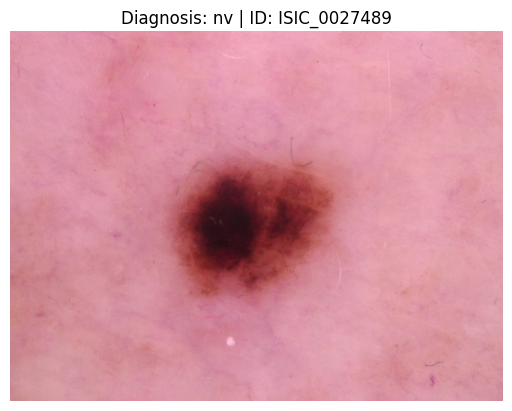

In [10]:
show_image("ISIC_0027489", df)

## Understanding the data

In this section, we are going to explore the columns of the dataset and inspect their contents. It is important to clearly understand the columns in order to know how to approach the problem.

In [11]:
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,image_path
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,/home/haizea_gonzalez/.cache/kagglehub/dataset...
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,/home/haizea_gonzalez/.cache/kagglehub/dataset...
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,/home/haizea_gonzalez/.cache/kagglehub/dataset...
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,/home/haizea_gonzalez/.cache/kagglehub/dataset...
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,/home/haizea_gonzalez/.cache/kagglehub/dataset...


The columns we have are:
- ***lesion_id***: Unique identifier of the lesion → TYPE string

- ***image_id***: Unique identifier of the image → TYPE string

- ***dx***: Diagnosis of the lesion. Useful for lesion classification → TYPE string
    
    **Benign**
    - **nv**: Melanocytic nevus (benign mole)
    - **bkl**: Benign keratosis-like lesions
    - **vasc**: Vascular lesion
    - **df**: Dermatofibroma (benign skin lesion)

    **Malignant**
    - **mel**: Melanoma (malignant skin cancer)
    - **bcc**: Basal cell carcinoma (skin cancer)
    - **akiec**: Actinic keratoses / intraepithelial carcinoma




- ***dx_type***: Indicates how the diagnosis was confirmed. Helps assess the reliability of the diagnosis → TYPE string
    - **histo**: Confirmed by histopathology (laboratory test)
    - **follow_up**: Confirmed by clinical follow-up
    - **consensus**: Confirmed by expert consensus
    - **confocal**: Confirmed by confocal microscopy

    With *histo* generally considered more reliable than *follow_up*, while less common values such as *consensus* and *confocal* indicate specialized confirmation.

- ***age***: Age of the patient in years → TYPE float

- ***sex***: Sex of the patient ('male', 'female', 'unknown') → TYPE string

- ***localization***: Anatomical location of the lesion on the body → TYPE string

- ***imag_path***: Full path to the image file in the dataset → TYPE string

### Exploratory Data Analysis

In this section we are going to get insights about the dataset. These will be very useful to know more about the data and to select the best way to go ahead with the problem.

#### Diagnosis distribution

##### Benign VS Malignant

One of the best ways to understand the data is to check for class imbalances, which can be easily visualized using a simple but effective distribution plot.

/tmp/ipykernel_1041/214184989.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='benign_malign', data=df, palette='coolwarm')


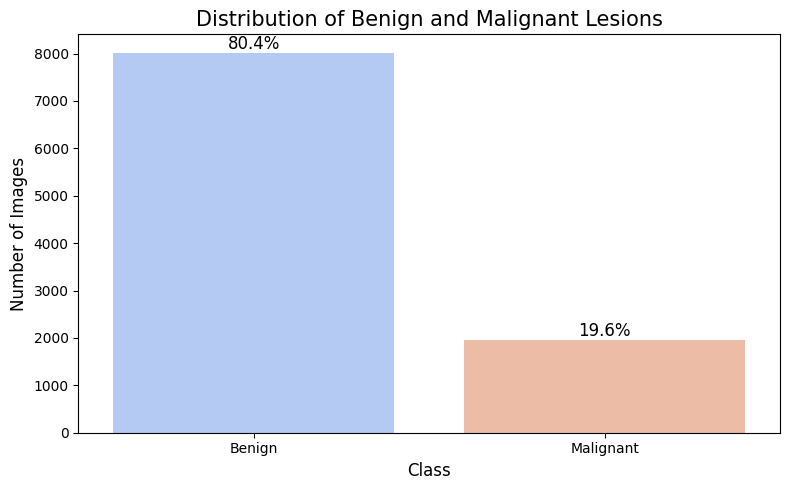

Distribution of Benign and Malignant Lesions:
 benign_malign
Benign       8006
Malignant    1952
Name: count, dtype: int64


In [12]:
# Get malignant classes
malignant = ['mel', 'bcc', 'akiec']

# Create binary column for benign vs malignant
df['benign_malign'] = df['dx'].apply(lambda x: 'Malignant' if x in malignant else 'Benign')

percentages = df['benign_malign'].value_counts(normalize=True) * 100

# Plot benign vs malignant
plt.figure(figsize=(8, 5))
sns.countplot(x='benign_malign', data=df, palette='coolwarm')

# Add percentages on top of bars
total = len(df)
for p in plt.gca().patches:
    height = p.get_height()
    percentage = height / total * 100
    plt.gca().annotate(f'{percentage:.1f}%', (p.get_x() + p.get_width() / 2, height),
                       ha='center', va='bottom', fontsize=12)

plt.title('Distribution of Benign and Malignant Lesions', fontsize=15)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.tight_layout()
plt.show()

# Count for report
print("Distribution of Benign and Malignant Lesions:\n", df['benign_malign'].value_counts())

As we see in the barplot, most of the samples are classified as Bening (80.5%). But to get deeper insights, we made additional plots so we can predict more precisely whether a cancer is malignant or benign, just from its image.

##### Lesion type distribution

We will repeat this plot among the seven different types of skin lesions in the dataset.

/tmp/ipykernel_1041/594728644.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, palette='magma')


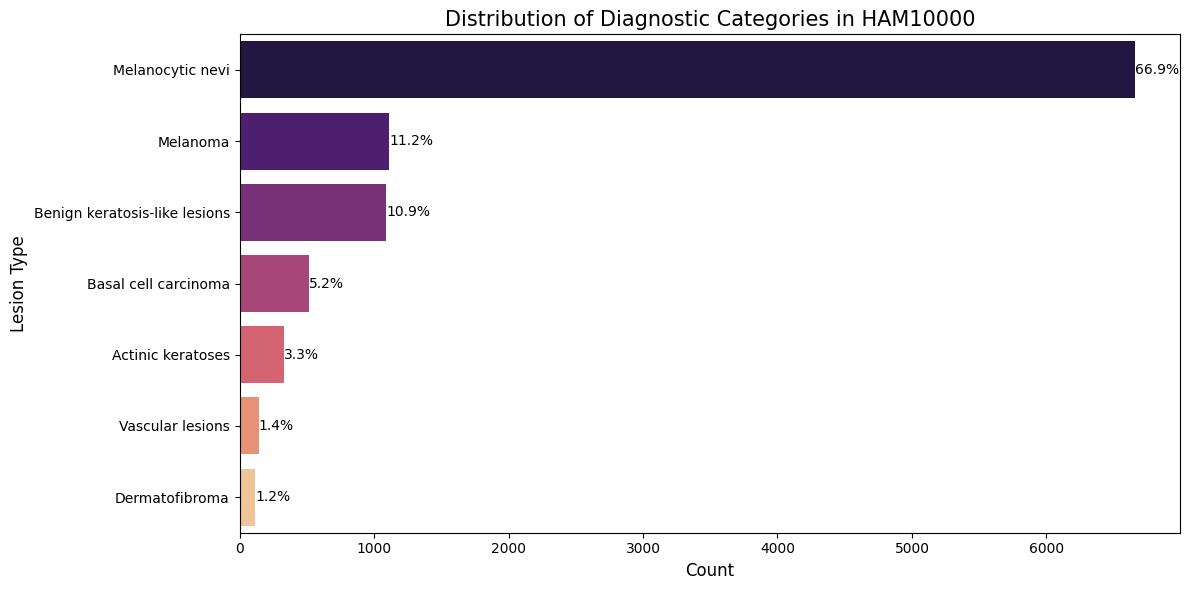

Class distribution:
 cell_type
Melanocytic nevi                 6660
Melanoma                         1111
Benign keratosis-like lesions    1089
Basal cell carcinoma              514
Actinic keratoses                 327
Vascular lesions                  142
Dermatofibroma                    115
Name: count, dtype: int64


In [13]:
# Mapping dictionary for full diagnostic names
dx_map = {
    'nv': 'Melanocytic nevi',
    'mel': 'Melanoma',
    'bkl': 'Benign keratosis-like lesions',
    'bcc': 'Basal cell carcinoma',
    'akiec': 'Actinic keratoses',
    'vasc': 'Vascular lesions',
    'df': 'Dermatofibroma'
}

# Add a more descriptive column
df['cell_type'] = df['dx'].map(dx_map)

# Plotting the distribution
plt.figure(figsize=(12, 6))
sns.countplot(y='cell_type', data=df, order=df['cell_type'].value_counts().index, palette='magma')

# Add percentages on top of bars
total = len(df)
for p in plt.gca().patches:
    width = p.get_width()
    percentage = width / total * 100
    plt.gca().annotate(f'{percentage:.1f}%', (width, p.get_y() + p.get_height() / 2),
                       ha='left', va='center', fontsize=10)

plt.title('Distribution of Diagnostic Categories in HAM10000', fontsize=15)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Lesion Type', fontsize=12)
plt.tight_layout()
plt.show()

# Print class counts for report
print("Class distribution:\n", df['cell_type'].value_counts())

The plot shows a significant class **imbalance among the seven classes**. Most of the samples are benign, with 'Melanocytic nevi' being the largest class. If we focus only on the malignant types [Melanoma (mel), Basal cell carcinoma (bcc), and Actinic keratoses (akiec)] we can see that these classes have fewer samples compared to the benign ones. This is a critical observation for our project, as it highlights the need for Data Augmentation and more robust evaluation metrics (such as F1-Score) to ensure the model doesn't simply bias towards the most frequent class.

#### Characteristics distribution

It is also useful to examine the distribution of numerical features. For instance, in this dataset, age may influence whether a lesion is benign or malignant, and such patterns can be detected through exploratory plots.

##### Age distribution Boxplot

We start with a boxplot to visualize the distribution of age for benign and malignant lesions. Boxplots provide a clear view of the median, interquartile range, and potential outliers, giving a quick summary of the age differences between classes.

/tmp/ipykernel_1041/2001720711.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='benign_malign', y='age', data=df, palette='coolwarm')


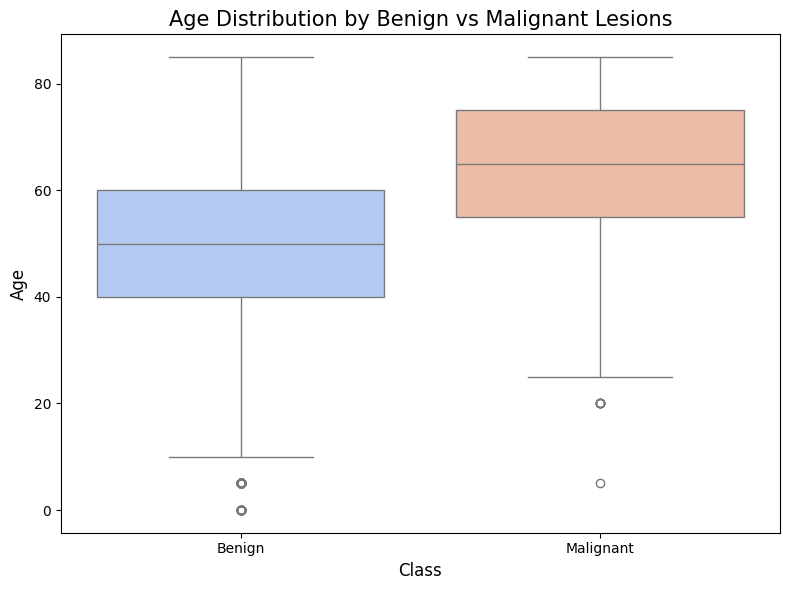

                count       mean        std  min   25%   50%   75%   max
benign_malign                                                           
Benign         8006.0  49.080689  16.344335  0.0  40.0  50.0  60.0  85.0
Malignant      1952.0  63.278689  14.534753  5.0  55.0  65.0  75.0  85.0


In [14]:
plt.figure(figsize=(8,6))
sns.boxplot(x='benign_malign', y='age', data=df, palette='coolwarm')
plt.title('Age Distribution by Benign vs Malignant Lesions', fontsize=15)
plt.xlabel('Class', fontsize=12)
plt.ylabel('Age', fontsize=12)
plt.tight_layout()
plt.show()

# Print age statistics by class for report
print(df.groupby('benign_malign')['age'].describe())

As shown by the descriptive statistics and the visualization, **age appears to influence** whether a lesion is benign or malignant. The mean age for benign lesions is approximately 49 years, while for malignant lesions it is about 63 years. Additionally, the interquartile ranges show that malignant lesions tend to occur at older ages, with 50% of malignant cases between 55 and 75 years. This supports the hypothesis that age is associated with malignancy in this dataset.

We can also observe that there are a few **outliers** in both categories. Some benign cases are as young as 0–5 years, and malignant cases include patients as young as 5 and 20 years. To further investigate the age distribution and identify potential outliers, we used the same boxplot combined with a stripplot.

The **stripplot** adds individual data points, allowing us to observe the density and spread of each sample. This visualization helps verify whether unusually young or old cases are genuine or possible data entry errors, providing a more detailed understanding of age differences between benign and malignant lesions.

/tmp/ipykernel_1041/2458983999.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='benign_malign', y='age', data=df, palette='coolwarm', showfliers=True)


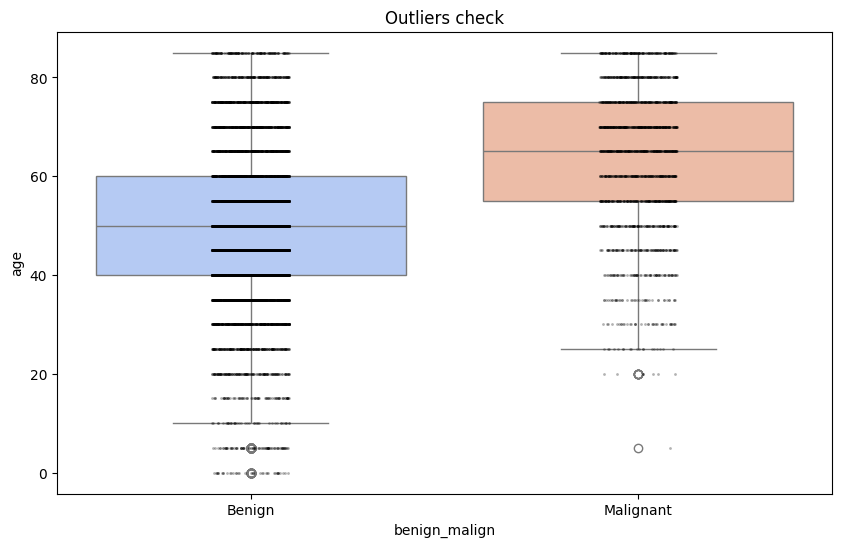

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='benign_malign', y='age', data=df, palette='coolwarm', showfliers=True)

# Density layer
sns.stripplot(x='benign_malign', y='age', data=df, color='black', size=2, alpha=0.3)
plt.title('Outliers check')
plt.show()

The black points far from the boxes (especially near 0) explain why the boxplot looked unusual at first.
- **For benign lesions**, it is normal to see many young children with ages around 0–5 years, as these usually correspond to birthmarks or vascular lesions.

- **For malignant lesions**, points at low ages are unusual, since skin cancer is extremely rare in children. These points are the “exceptions” to the general pattern.

In summary, the plot shows that most malignant cases occur in older individuals, but the isolated black points at younger ages remind us that there are **true exceptions**, which we will not remove, as the model must also be able to detect them.


##### Kerner Density Estimate

Now, we will use a KDE plot to observe the overall shape of the age distribution for each class. This allows us to see patterns, and make sure that certain age ranges are more common for malignant or benign lesions.

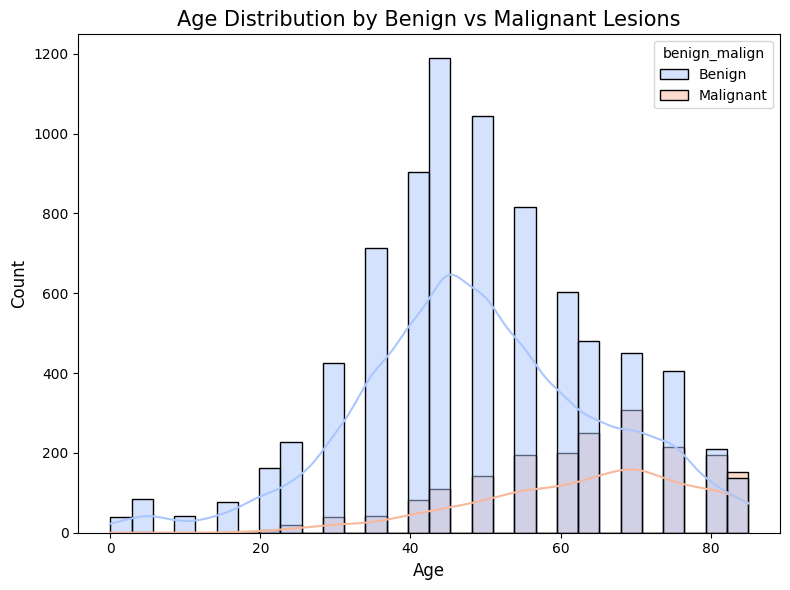

In [16]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x='age', hue='benign_malign', kde=True,
             bins=30, palette='coolwarm', alpha=0.5)
plt.title('Age Distribution by Benign vs Malignant Lesions', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.tight_layout()
plt.show()

The KDE plot also shows that benign lesions usually happen at younger ages than malignant ones. The distribution of benign cases is bell-shaped, meaning that most cases are around the same age, even though it’s not a perfect bell. On the other hand, malignant cases have a more irregular distribution, showing that they can appear over a wider range of ages.

##### Normalized KDE

Finally, we use a normalized KDE plot to compare the ages of benign and malignant lesions. This lets us focus on the shape of the age distributions without being affected by the number of cases in each class.

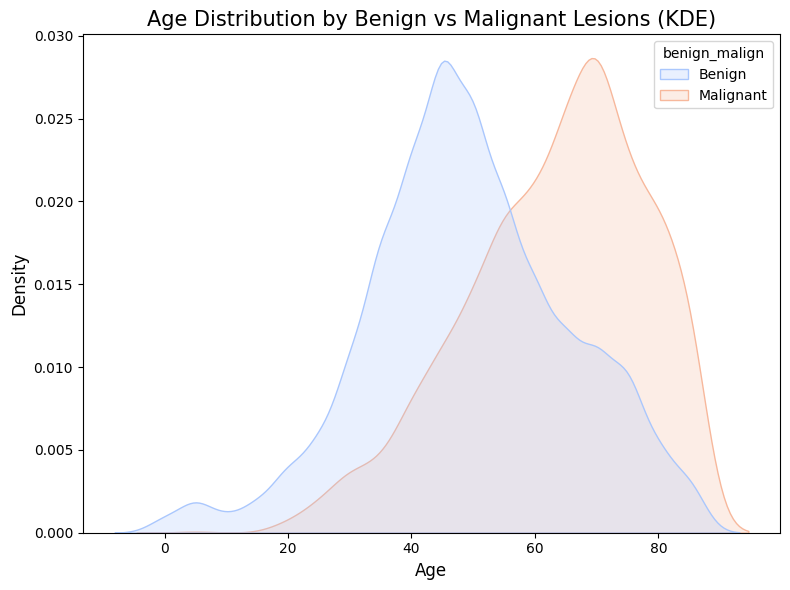

In [17]:
plt.figure(figsize=(8,6))
sns.kdeplot(data=df, x='age', hue='benign_malign', palette='coolwarm', fill=True, common_norm=False)
plt.title('Age Distribution by Benign vs Malignant Lesions (KDE)', fontsize=15)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.tight_layout()
plt.show()

The plot shows that benign lesions usually occur at younger ages with a roughly bell-shaped pattern, while malignant lesions are more spread out. This supports the idea that age is related to whether a lesion is benign or malignant.

##### Correlation Heatmap: Location VS Diagnosis

Now, we are going to use a correlation heatmap to see if each class tends to appear more frequently in a specific body location. This will be useful, as it could be used as an additional feature in the model to improve its predictions.

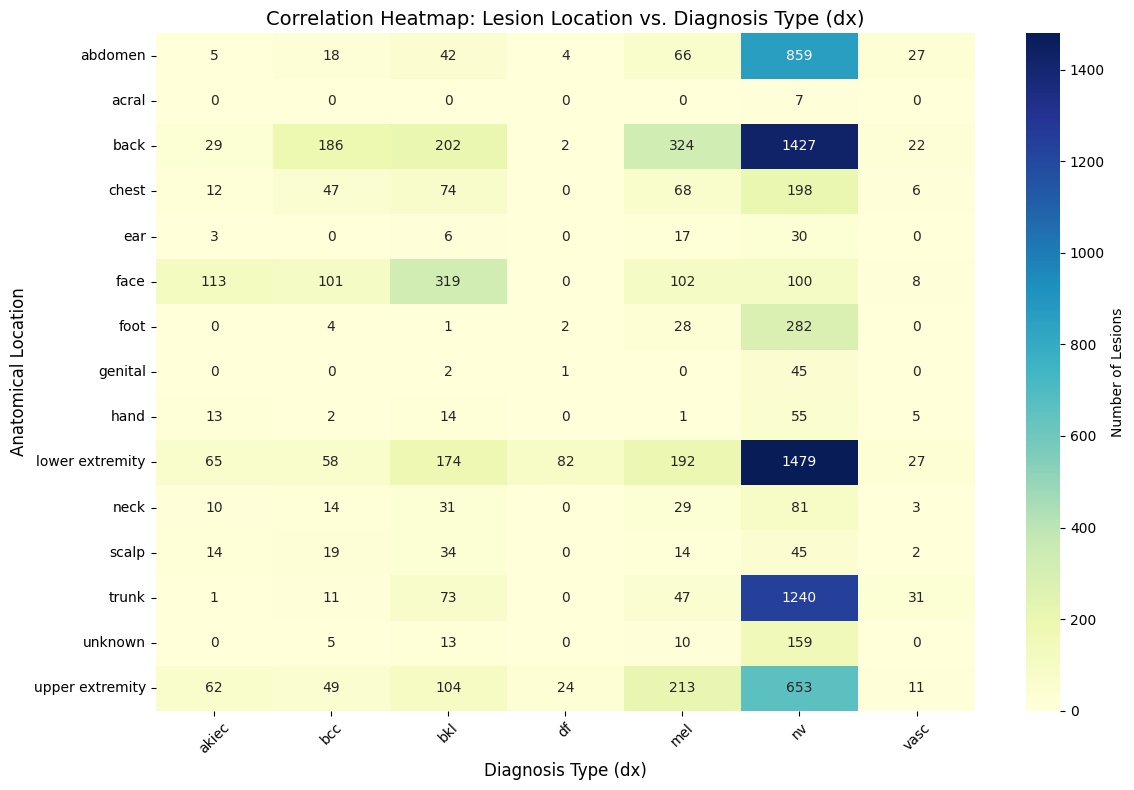

In [18]:
# Contingency table for localization vs diagnosis (needed as are categorical variables)
contingency_table = pd.crosstab(df['localization'], df['dx'])

# Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    contingency_table,
    annot=True,
    fmt='d',
    cmap='YlGnBu',
    cbar_kws={'label': 'Number of Lesions'}
)

# Add labels and title
plt.title('Correlation Heatmap: Lesion Location vs. Diagnosis Type (dx)', fontsize=14)
plt.xlabel('Diagnosis Type (dx)', fontsize=12)
plt.ylabel('Anatomical Location', fontsize=12)

# Rotate labels so they do not overlap
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

From the plot, we can see that certain classes tend to appear more frequently in specific body areas. For example, 'Melanocytic nevi' are mostly found on the trunk and lower limbs, while 'Basal cell carcinoma' occurs more often on the head and neck.

However, **to avoid misleading conclusions** due to the large differences in class sizes, we will normalize the counts by column to show the proportion of each diagnosis within each anatomical location. This will allow us to see which classes are relatively more common in each location, independently of their overall frequency. **Normalizing by column** ensures that we can identify the anatomical areas where each diagnosis is relatively concentrated, rather than being dominated by the larger classes. This information could be useful as an additional feature to improve the predictive performance of the model.

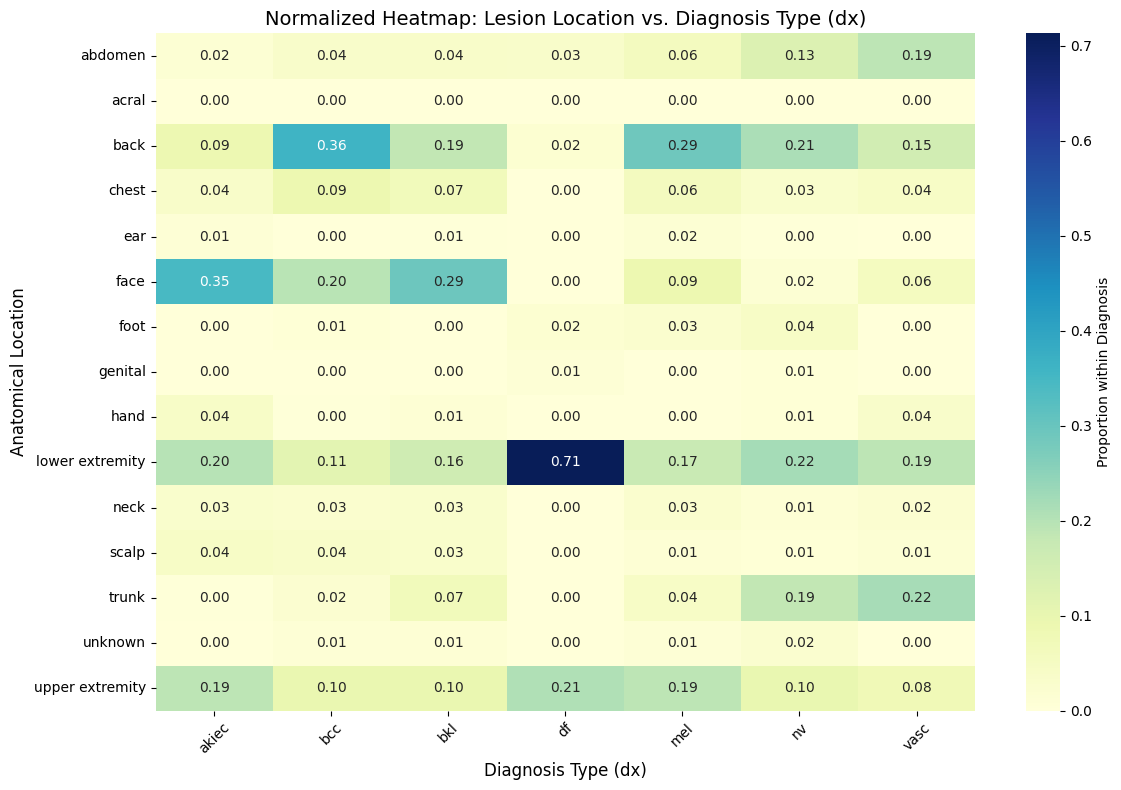

In [19]:
# Normalize the contingency table by row to see the distribution of diagnoses within each location
contingency_table_norm = pd.crosstab(df['localization'], df['dx'], normalize='columns')

# Create the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(
    contingency_table_norm,
    annot=True,
    fmt='.2f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Proportion within Diagnosis'}
)

# Add labels and title
plt.title('Normalized Heatmap: Lesion Location vs. Diagnosis Type (dx)', fontsize=14)
plt.xlabel('Diagnosis Type (dx)', fontsize=12)
plt.ylabel('Anatomical Location', fontsize=12)

# Rotate labels so they do not overlap
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()

# Show the plot
plt.show()

From the normalized table, we can see that **some diagnoses are strongly associated with specific locations**. For example, Dermatofibromas are mostly on the lower extremities, and Actinic keratoses are mainly on the face. Other classes, like Melanoma and Melanocytic nevi, are more spread out but still show higher proportions on the back and lower extremities. This suggests that **anatomical location could be a useful additional feature for the model**, as it may help improve predictions for certain lesion types.

##### Distribution by Anatomical Location

To better understand the relationship between anatomical location and lesion type, we created a plot showing the proportion of benign and malignant lesions for each body location.

In this case, **normalization by row (localization)** is necessary because most lesions in the dataset are benign, and using absolute counts would make it difficult to identify locations with a higher relative proportion of malignant cases. By normalizing, each row sums to 1, allowing us to clearly see the percentage of malignant vs benign lesions in each location. This approach provides a more accurate view of which locations may be more strongly associated with malignancy and can be useful as an additional feature in the predictive model. Based on the previous heatmap with detailed diagnoses, we observed that **normalization improves interpretability and highlights meaningful patterns that are not visible when using raw counts**.

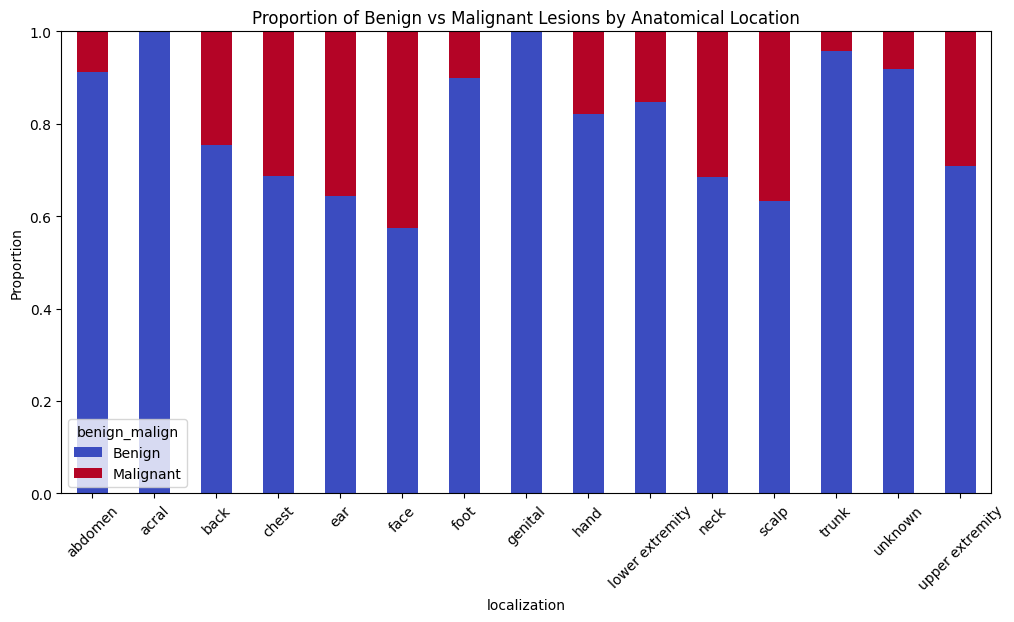

In [20]:
# Normalize per column to see the distribution of locations within each diagnosis
contingency = pd.crosstab(df['localization'], df['benign_malign'], normalize='index')

# Bar plot with proportions
contingency.plot(kind='bar', stacked=True, figsize=(12,6), colormap='coolwarm')
plt.ylabel('Proportion')
plt.title('Proportion of Benign vs Malignant Lesions by Anatomical Location')
plt.xticks(rotation=45)
plt.show()

As we can see in the plot, locations like the face, ear, scalp, chest and neck have a higher proportion of malignant lesions, while areas such as the abdomen, trunk, and foot are mostly benign. Small locations like genital, or acral regions have very few (although it is not visible in the plot, if we print the contingency table, there is a few percentage) we malignant cases. Normalizing by location allows us to see the relative proportion of malignancy, avoiding misleading results due to the large number of benign lesions. This suggests that **anatomical location could be used as an additional feature in the model**, as it provides useful information about the likelihood of a lesion being malignant in specific body areas.

##### Correlation Heatmap: Location VS Sex

To have more insight into the dataset, we are analyzing how sex is distributed across different anatomical locations. By creating a normalized heatmap, we can see the proportion of males and females in each location. This helps identify potential patterns, such as certain locations being more common in one sex, which could be useful as an additional feature in the predictive model. As we saw in previous plots, normalization ensures that differences in sample sizes between locations do not distort the interpretation.

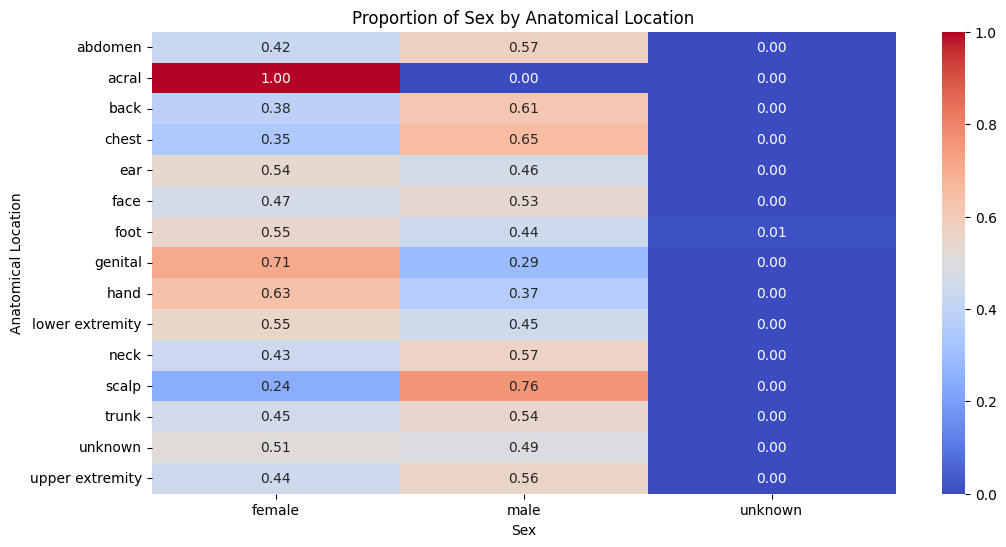

In [21]:
# Contingency table
contingency = pd.crosstab(df['localization'], df['sex'], normalize='index')

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(contingency, annot=True, fmt='.2f', cmap='coolwarm')

# Add labels and title
plt.title('Proportion of Sex by Anatomical Location')
plt.ylabel('Anatomical Location')
plt.xlabel('Sex')

# Show the plot
plt.show()

As we can see, all lesions in the acral region are female in this dataset, while the scalp is mostly male (≈76%). Other locations, like the abdomen, face, and trunk, are more balanced between sexes. Small categories or locations with few samples may show extreme proportions but are less reliable. These patterns suggest that sex could be related to lesion location and may be considered as an additional feature in the predictive model.

##### Correlation Heatmap: Benign/Malignant VS Sex

We think it is also important to understand the relationship between sex and lesion type. To do this, we will examine the distribution of benign and malignant lesions across sexes.

We normalized the contingency table by row, that is, by benign and malignant lesions, to show the proportion of males and females within each lesion type. This allows us to see the sex distribution for benign and malignant lesions separately, without being affected by the larger number of benign cases.

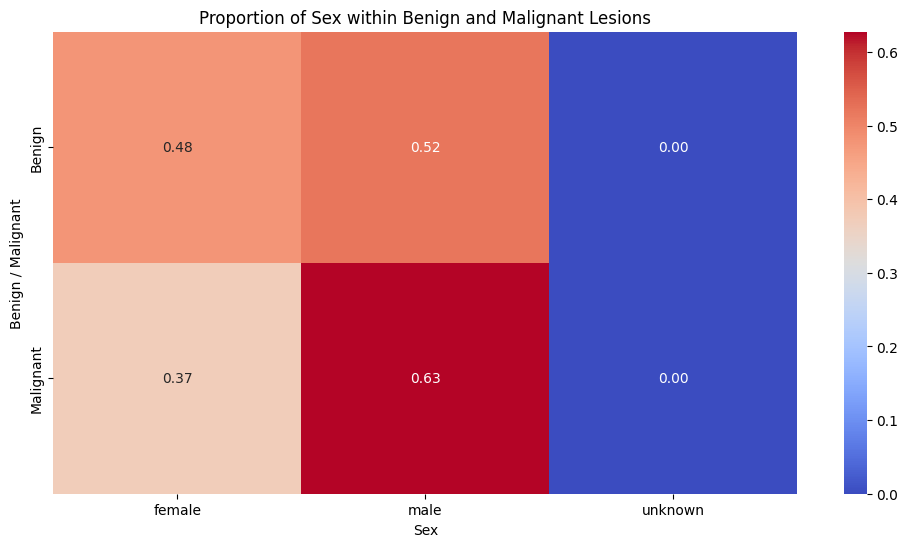

In [22]:
# Contingency table
contingency = pd.crosstab(df['benign_malign'], df['sex'], normalize='index')

# Heatmap
plt.figure(figsize=(12,6))
sns.heatmap(contingency, annot=True, fmt='.2f', cmap='coolwarm')

# Add labels and title
plt.title('Proportion of Sex within Benign and Malignant Lesions')
plt.ylabel('Benign / Malignant')
plt.xlabel('Sex')

# Show the plot
plt.show()

The plot shows the proportion of females, males, and unknown within benign and malignant lesions. Among benign lesions, females and males are roughly balanced (≈47% vs 52%), while malignant lesions are more common in males (≈63%). Unknown sex is very small and mostly present in benign cases. This suggests that sex could have some relationship with malignancy, which may be useful as an additional feature in the model.

# Conclusions

As we have seen, there is a **big data imbalance** between lesion classes and between benign and malignant cases. To handle it, we may need SMOTE, data augmentation, or GAN-generated images to improve the model and help it detect rare classes.

On the other hand, the EDA helps answer some key questions: which features should we use in the model?

1. **Image (the main feature)**: It is the key aspect of the project. Without it, there is no diagnosis.

2. **Age**: As we saw, it is highly relevant. Analysis shows a clear correlation with malignancy Malignant lesions appear in older patients (mean ~63 years) compared to benign ones (~49 years). Boxplots and KDE plots confirm this. For the model: include age as a numerical feature to improve class differentiation, especially for borderline cases.

3. **Sex**: It is relevant, with some caution. Heatmaps show malignant lesions are more common in males (~63% vs 37%). Unknown sex is rare and should be handled carefully (for example, impute or treat as a separate category). For the model: include sex as a categorical feature in the multimodal model.

4. **Anatomical Location**: It is highly relevant. Proportion analysis shows some body areas are more prone to malignancy (face, ears, scalp), while others mostly have benign lesions (trunk, lower limbs). This allows the model to learn anatomical patterns, for example, a lesion on the face is more likely bcc or akiec.

5. **Diagnosis Method (dx_type)**: We will not use as input. This column describes how the diagnosis was obtained (biopsy, follow-up, consensus). Using it would cause data leakage, because in a real scenario you do not know this before prediction.

In summary, the image is the most important feature, while age, sex, and anatomical location provide useful additional information. The diagnosis method will not be used to avoid data leakage.

Considering the data imbalance, we will apply techniques like SMOTE, data augmentation, or GAN-generated images to improve the model and make it more reliable for rare classes.

With these features and strategies, we are ready to build a multimodal model that combines visual and contextual information for better lesion classification.

## Data Preprocessing

### Configuration for model training

This part sets the main parameters for preprocessing the data:
- ***IMG_SIZE***: The size of the images for the CNN (e.g., 128x128). All images need the same size.
- ***NUM_CLASSES***: How many lesion classes you have (7 for HAM10000).
- ***RANDOM_STATE***: Fixes the randomness so results are reproducible.

In [23]:
IMG_SIZE = (128, 128)   # cambiar a (224,224) para transfer learning
NUM_CLASSES = 7
RANDOM_STATE = 111

### Split without data leakage

We do not want the model to see the same lesion in both training and testing, because some lesions share the same ID. If that happens, the model could "cheat."  

To prevent this:
- We split the dataset by `lesion_id` so that each lesion appears only in one set.
- First, we divide the lesions into training (70%) and temporary (30%).
- Then, we split the temporary set equally into validation (15%) and test (15%).

This ensures that no lesion appears in more than one set, which is important for evaluating real-world performance.

In [24]:
# Ensure that all images from the same lesion_id are in the same split to prevent data leakage
unique_lesions = df['lesion_id'].unique()

# Split the unique lesion IDs into train, validation, and test sets
train_ids, temp_ids = train_test_split(
    unique_lesions,
    test_size=0.30,
    random_state=RANDOM_STATE
)

val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=RANDOM_STATE
)

# Create DataFrames for each split based on lesion_id
train_df = df[df['lesion_id'].isin(train_ids)].copy()
val_df   = df[df['lesion_id'].isin(val_ids)].copy()
test_df  = df[df['lesion_id'].isin(test_ids)].copy()

print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

Train: 6919, Val: 1520, Test: 1519


### Load and preprocess images

It is necessary to check and preprocess images so we can use them into the models. For that, we
1. Open each image using PIL and make sure it has RGB channels.
2. Resize the image to the target size (128x128).
3. Apply normalization: convert the pixel values to numbers between 0 and 1 by dividing by 255.
4. Convert the image array from (H, W, C) to (C, H, W), as PyTorch models expect channel-first tensors.

This is necessary as **CNNs require uniform input size and normalized pixel values to train properly**.

In [25]:
def load_images(df, target_size):
    images = []
    for path in df['image_path']:
        img = Image.open(path).convert("RGB")
        img = img.resize(target_size)
        # Cargamos como entero (0-255) para ahorrar RAM
        images.append(np.asarray(img, dtype=np.uint8)) 
    
    # Transponemos a (N, C, H, W) al final
    images_array = np.array(images).transpose(0, 3, 1, 2)
    return torch.tensor(images_array, dtype=torch.uint8) # Usamos uint8 aquí


# Apply the function to load and preprocess images for each split
X_train_tensor = load_images(train_df, IMG_SIZE)
X_val_tensor = load_images(val_df, IMG_SIZE)
X_test_tensor = load_images(test_df, IMG_SIZE)

print("Image shapes:")
print(X_train_tensor.shape, X_val_tensor.shape, X_test_tensor.shape)

Image shapes:
torch.Size([6919, 3, 128, 128]) torch.Size([1520, 3, 128, 128]) torch.Size([1519, 3, 128, 128])


### Labels

We need to transform the labels into numerical categories. For this, we:

- Convert the textual diagnosis (`dx`) into numbers using a `LabelEncoder`.
- Convert these numbers into PyTorch tensors of type `long` because `CrossEntropyLoss` expects integer class labels.

**Important:** We only fit the encoder on the training data to avoid leaking information from the validation or test sets.

We also save the encoder to disk so we can use it later for predictions.

In [26]:
# Create label encoders for the target variable
le = LabelEncoder()

y_train_labels = le.fit_transform(train_df['dx']) # Fit on train to avoid data leakage
y_val_labels   = le.transform(val_df['dx'])
y_test_labels  = le.transform(test_df['dx'])

# Convert to PyTorch tensors (long for CrossEntropyLoss)
y_train_tensor = torch.tensor(y_train_labels, dtype=torch.long)
y_val_tensor   = torch.tensor(y_val_labels, dtype=torch.long)
y_test_tensor  = torch.tensor(y_test_labels, dtype=torch.long)

# Save encoder
pickle.dump(le, open("label_encoder.pkl", "wb"))

print("Labels shapes:", y_train_tensor.shape, y_val_tensor.shape, y_test_tensor.shape)

Labels shapes: torch.Size([6919]) torch.Size([1520]) torch.Size([1519])


### Metadata for multimodal architectures

We also include non-image features like age, sex, and anatomical location. For this, we:

- **Age**: Standardize to have mean 0 and standard deviation 1, so it is on the same scale as other features.
- **Sex and localization**: Convert categorical values into one-hot encoding.
- **Align columns**: Make sure that training, validation, and test metadata have exactly the same columns, filling missing categories with 0 if necessary.
- **Convert to PyTorch tensors**: This allows the model to use both clinical metadata and images together.

This ensures that the model can leverage clinical information alongside the images without dimension mismatches.

In [27]:
# --- AGE ---
scaler = StandardScaler()
train_df['age'] = scaler.fit_transform(train_df[['age']])
val_df['age']   = scaler.transform(val_df[['age']])
test_df['age']  = scaler.transform(test_df[['age']])

# Sex and localization --> One-hot encoding
train_meta = pd.get_dummies(train_df[['age', 'sex', 'localization']])
val_meta   = pd.get_dummies(val_df[['age', 'sex', 'localization']])
test_meta  = pd.get_dummies(test_df[['age', 'sex', 'localization']])

# Align columns across splits
train_meta, val_meta = train_meta.align(val_meta, join='left', axis=1, fill_value=0)
train_meta, test_meta = train_meta.align(test_meta, join='left', axis=1, fill_value=0)

# Convert to PyTorch tensors
X_train_meta_tensor = torch.tensor(train_meta.values.astype(np.float32))
X_val_meta_tensor   = torch.tensor(val_meta.values.astype(np.float32))
X_test_meta_tensor  = torch.tensor(test_meta.values.astype(np.float32))

print("Metadata shapes (PyTorch tensors):")
print(X_train_meta_tensor.shape, X_val_meta_tensor.shape, X_test_meta_tensor.shape)

Metadata shapes (PyTorch tensors):
torch.Size([6919, 19]) torch.Size([1520, 19]) torch.Size([1519, 19])


### Class Weights

The HAM10000 dataset is imbalanced (e.g., very few malignant cases). To handle this:

- Compute class weights using `sklearn` so that rarer classes are given more importance.
- Convert the weights to PyTorch tensors to use them in the loss function during training.

This helps the model avoid bias toward the majority classes and improves performance on underrepresented categories.

In [28]:
y_train_labels = y_train_tensor.numpy()  # Convert to numpy for sklearn

# Compute class weights (balanced)
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_labels),
    y=y_train_labels
)

# Convert to PyTorch tensor
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)

print("Class weights tensor for PyTorch:", class_weights_tensor)

Class weights tensor for PyTorch: tensor([ 4.6845,  2.5151,  1.3144, 13.0056,  1.3393,  0.2130,  9.1521])


### Data Augmentation

One of the main challenges in training deep learning models for dermatology is the **high variability of clinical photography**. Unlike standardized laboratory images, skin lesion photos are taken in different environments, with varying angles, distances, and lighting conditions.

If we train our model only on the "static" original images, we risk **overfitting**: the model might memorize the specific orientation or position of a lesion rather than learning its actual biological features. To build a system that is truly useful in a real-world clinic, we need to ensure it is invariant to these external factors.

Instead of using a standard, fixed pipeline, we have designed a Combinatorial Augmentation strategy using the `RandomOneOrMoreAugment` class. This approach serves three critical purposes:
- **Increasing Visual Robustness**: By randomly rotating, flipping, and adjusting the color of images, we teach the network that a diagnosis remains the same regardless of how the photo was taken.
- **Dataset Expansion**: It effectively "multiplies" our training data. This is vital for the HAM10000 dataset, as it helps the model better understand minority classes (like Melanoma or BCC) by seeing them in thousands of different "synthetic" variations.
- **Simulating Clinical Reality**: The use of *RandomResizedCrop* and *ColorJitter* mimics the reality of a doctor using a smartphone or a dermatoscope—sometimes closer, sometimes further away, and under different room lights.
By forcing the model to deal with these transformations during training, we "harden" its intelligence, making it **focus on the texture, edges, and colors** of the pathology rather than the accidental details of the photograph.

In [29]:
class RandomOneOrMoreAugment:
    def __init__(self, transforms_list):
        # Set the list of transformations to choose from
        self.transforms_list = transforms_list

    def __call__(self, img):
        # Select randomly between 1 and the total number of defined transformations
        num_to_apply = random.randint(1, len(self.transforms_list))
        chosen = random.sample(self.transforms_list, k=num_to_apply)
        for transform in chosen:
            img = transform(img)
        return img


In [30]:
# Possible augmentations for training data (applied randomly with the custom class above).
# It is included small adjustments of color and rotation, ideal for skin.
augmentation_candidates = [ 
    transforms.RandomHorizontalFlip(p=0.5),  # Always apply horizontal flip when chosen
    transforms.RandomVerticalFlip(p=0.5), # Always apply vertical flip when chosen
    transforms.RandomRotation(25), # Rotate randomly within a range of -25 to 25 degrees
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # Adjust brightness and contrast slightly
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)), # Randomly crop and resize back to 128x128, simulating zoom and shift
]

To implement our strategy, we define **two distinct pipelines** using *transforms.Compose*. While they share the same objective of preparing images for the neural network, their roles are fundamentally different:

- `train_transform_fn` (**Training Pipeline)**: By integrating the RandomOneOrMoreAugment class, we ensure that every time the model "sees" an image during an epoch, **it looks slightly different**.
    - **Normalization**: We scale the pixel values to a range of $[-1, 1]$ (mean and std of 0.5). This helps the gradients flow better during backpropagation, making the training more stable.
    - **Resizing**: We standardize all images to $128 \times 128$ pixels, balancing the need for visual detail with computational efficiency.

-  `val_transform` **(Validation/Testing Pipeline)**: Unlike the training set, we do not augment the validation data.
    - **Consistency is Key**: To truly measure the model's progress, we need to test it against "clean" realistic images. If we augmented the validation set, our accuracy metrics would fluctuate due to the transformations, not the model's actual performance.
    - **Parity**: We maintain the same Resizing and Normalization as the training set to ensure the data distribution remains identical, but without the "noise" of random flips or rotations.

In [31]:
train_transform_fn = transforms.Compose([
    transforms.ToPILImage(),
    RandomOneOrMoreAugment(augmentation_candidates),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    
])
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

As we know, in the HAM10000 dataset, there is a **massive class imbalance**. For instance, there are thousands of "Nevus" (healthy moles) but only a few dozen "Vascular" lesions. If we train the model normally, it will become "lazy" and learn to predict the majority class almost every time to get a high accuracy score.

To prevent this, we calculate Sample Weights to ensure that every disease gets the same amount of "attention" during training.

**How it works:**
- `class_counts`: We count how many images exist for each of the 7 classes.
- `class_weights`: We calculate the inverse of the counts. Rare classes get a high weight, while common classes get a low weight.
- `sample_weights`: We assign a specific weight to every single image in the training set based on its class.

These weights will be used later by a `WeightedRandomSampler` in our DataLoader. Instead of showing the model images in their original order, the Sampler uses these weights to "pick" images for each batch. This means that in every training step, the model will see a balanced mix of all classes, regardless of how many original images exist. By doing this, we force the model to **learn the unique features of rare cancers just as much as the features of common moles**.

In [32]:
class_counts = torch.bincount(y_train_tensor)
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_train_tensor]

## Simple CNN Implementation
Before moving to complex architectures or Transfer Learning, we implement a custom Convolutional Neural Network (CNN) from scratch. This serving as our baseline allows us to understand the raw difficulty of the dataset and justifies the need for more advanced techniques later on.

**Architecture Overview**

This model follows a classic hierarchical structure designed to capture increasingly complex visual patterns:

- **Spatial Feature Extraction**: Three convolutional blocks that use filters to detect basic shapes (edges, dots) and eventually complex textures characteristic of skin lesions.

- **Dimensionality Reduction**: Max-Pooling layers to reduce the spatial size of the features while keeping the most important information.

- **Classification Head**: A flattening layer followed by fully connected (Dense) layers that translate these spatial patterns into one of the 7 diagnostic categories.


In [33]:
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU available: True
GPU name: NVIDIA GeForce RTX 5060 Ti


We have to create the `ImageDataset` class to wrap the images and labels so PyTorch can work with them easily. It is like a container for your data that knows:
- How many items there are (`__len__`)
-  How to get a single item (`__getitem__`) it gives you an image and its label.

With this, we can also apply transformations (like rotations, flips, or resizing) automatically when you get an image.

In [34]:
class ImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        """
        images: image tensor (N, C, H, W)
        labels: class labels tensor (N,)
        transform: image transformations (data augmentation) to apply on the images
        """
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

We set `BATCH_SIZE = 32`. This is the number of images the model "sees" before updating its internal weights. A batch of 32 is large enough to provide a stable gradient (the direction the model needs to learn) but small enough to maintain "stochastic noise," which helps the model escape local minima and generalize better to unseen data.

We also wrap our tensors into the ImageDataset class. Here, the transform function acts as a real-time preprocessor:
- **Training Set**: We apply `train_transform_fn` (which includes our random rotations and flips). This ensures that the model almost never sees the exact same image twice, effectively acting as a "regulator" against overfitting.
- **Validation and Test Sets**: We apply `val_transform`. This only resizes and normalizes the images. We never apply random augmentations to these sets because we need a stable and realistic environment to measure the model's true accuracy.

In [ ]:
BATCH_SIZE = 32

train_dataset = ImageDataset(X_train_tensor, y_train_tensor, transform=train_transform_fn)
val_dataset   = ImageDataset(X_val_tensor, y_val_tensor, transform=val_transform)


Finally, we use DataLoaders to manage the flow of data:
- **Weighted Sampler**: Instead of a simple shuffle, we use a `WeightedRandomSampler`. This ensures that each batch contains a balanced representation of all 7 classes, even if some classes have very few images in the original dataset.
-  **No Shuffle in Validation**: We keep `shuffle=False` for validation and testing. This ensures that our evaluation is consistent and reproducible every time we run the metrics.

In [36]:
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

In [37]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Now, we import the SimpleCNN model, which is our small convolutional neural network for image classification. The inputs for the model are:
- `input_channels=3` because our images are RGB (3 color channels).
- `num_classes=7` because we have 7 different types of skin lesions to classify.
- `dropout_rate=0.5` this randomly “drops” 50% of neurons during training to reduce overfitting.

We also define the **criterion** for the loss function. In this case, `CrossEntropyLoss` as we are doing multi-class classification. We also add the `class_weights_tensor` trying to help handleling class imbalance.

For the **optimizer** we use `ADAM` with a learning rate of *1e-4*.

In [38]:
from models.simple_cnn import SimpleCNN

device = "cuda" if torch.cuda.is_available() else "cpu"
model = SimpleCNN(input_channels=3, num_classes=7, dropout_rate=0.5).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Now, we are going to train the model. For that, we will use the training function with **early stopping**, which means the model will keep training until the validation loss stops improving for a certain number of epochs (patience). This prevents the model from overfitting.

In [39]:
from utils import train_model

trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=200,
    patience=10,
    save_path="checkpoints/best_simple_cnn.pth"
)

Epoch 1/200 | Train Loss: 1.1605 Acc: 0.3028 | Val Loss: 3.3357 Acc: 0.1039
Epoch 2/200 | Train Loss: 0.9250 Acc: 0.3674 | Val Loss: 3.0748 Acc: 0.1046
Epoch 3/200 | Train Loss: 0.8197 Acc: 0.4194 | Val Loss: 2.7335 Acc: 0.1809
Epoch 4/200 | Train Loss: 0.7585 Acc: 0.4538 | Val Loss: 2.7672 Acc: 0.2039
Epoch 5/200 | Train Loss: 0.6988 Acc: 0.4738 | Val Loss: 3.1054 Acc: 0.1632
Epoch 6/200 | Train Loss: 0.6926 Acc: 0.4808 | Val Loss: 2.6524 Acc: 0.2079
Epoch 7/200 | Train Loss: 0.6582 Acc: 0.4918 | Val Loss: 2.6909 Acc: 0.1842
Epoch 8/200 | Train Loss: 0.6187 Acc: 0.5066 | Val Loss: 2.4985 Acc: 0.2671
Epoch 9/200 | Train Loss: 0.6005 Acc: 0.5170 | Val Loss: 2.8012 Acc: 0.2243
Epoch 10/200 | Train Loss: 0.5363 Acc: 0.5495 | Val Loss: 2.2514 Acc: 0.2961
Epoch 11/200 | Train Loss: 0.5539 Acc: 0.5449 | Val Loss: 2.4020 Acc: 0.3066
Epoch 12/200 | Train Loss: 0.5119 Acc: 0.5693 | Val Loss: 2.2371 Acc: 0.2914
Epoch 13/200 | Train Loss: 0.5197 Acc: 0.5559 | Val Loss: 2.5321 Acc: 0.2750
Epoch 14

After training, we can load this best model and test it on the test set to see how well it performs. It is also perfect if you only want to prove the trained model.

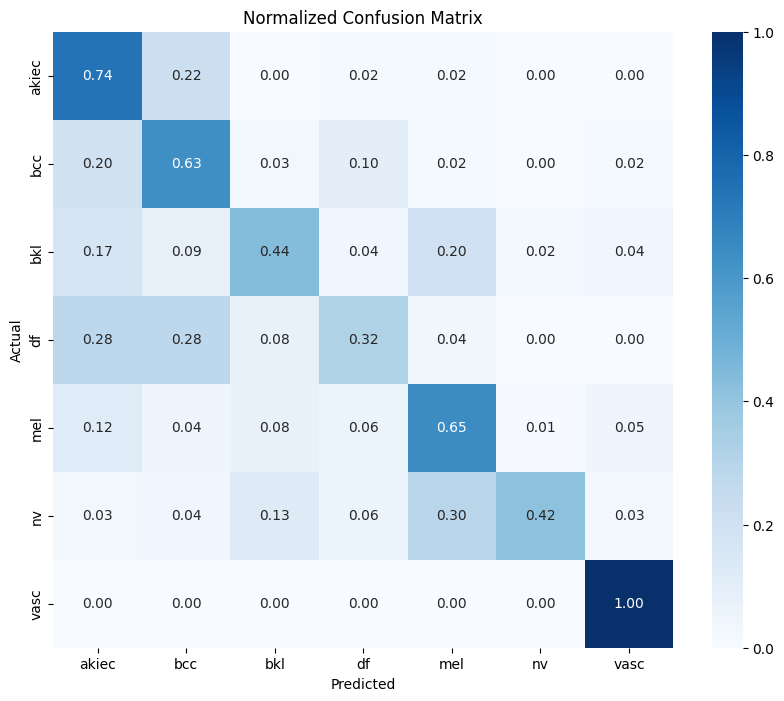

Confusion Matrix (normalized):
 [[0.74074074 0.22222222 0.         0.01851852 0.01851852 0.
  0.        ]
 [0.2        0.63333333 0.03333333 0.1        0.01666667 0.
  0.01666667]
 [0.17204301 0.08602151 0.44086022 0.03763441 0.20430108 0.02150538
  0.03763441]
 [0.28       0.28       0.08       0.32       0.04       0.
  0.        ]
 [0.12154696 0.0441989  0.07734807 0.05524862 0.64640884 0.00552486
  0.04972376]
 [0.03393214 0.03892216 0.1257485  0.05988024 0.29540918 0.41716567
  0.02894212]
 [0.         0.         0.         0.         0.         0.
  1.        ]]
Classification Report:
               precision    recall  f1-score   support

       akiec       0.27      0.74      0.40        54
         bcc       0.32      0.63      0.42        60
         bkl       0.36      0.44      0.40       186
          df       0.09      0.32      0.14        25
         mel       0.26      0.65      0.37       181
          nv       0.99      0.42      0.59      1002
        vasc       0.1

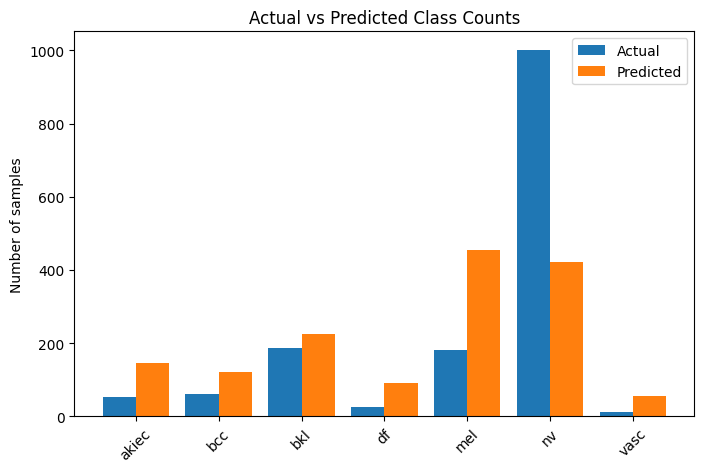

actual_counts: [  54   60  186   25  181 1002   11]
pred_counts: [147 120 226  92 454 423  57]


In [40]:
from utils import evaluate_model

# Create a new instance of the model and load the best weights
simple_model = SimpleCNN(input_channels=3, num_classes=7, dropout_rate=0.5).to(device)
simple_model.load_state_dict(torch.load("checkpoints/best_simple_cnn.pth", map_location=device))

# Create test DataLoader
BATCH_SIZE = 32
test_dataset = ImageDataset(X_test_tensor, y_test_tensor, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

all_labels, all_preds = evaluate_model(simple_model, test_loader, device, le)

### Analysis of Results (Simple CNN)

In this computational dermatology project, the goal is not just to get a high overall "Accuracy", but to minimize the risk of missing malignant lesions. As we saw, we can group the classes into two critical categories:
- Malignant (Cancer): mel, bcc, akiec.
- Benign/Others: nv, bkl, df, vasc.

**Evaluating Malignant Classes (High Priority)**
For cancer detection, the most important metric is **Recall (Sensitivity)**. We want the model to catch as many real cases as possible, even if it causes some false alarms.

- **Melanoma (mel)**: It shows a Recall of 0.65. This means the model is successfully catching 65% of the most aggressive cancers. However, the Precision is quite low (0.26), meaning there is a high number of false positives. The model is clearly playing it "safe" by over-predicting melanoma just in case.

- **Basal Cell Carcinoma (bcc)**: We achieved a Recall of 0.63. The model identifies over 60% of these cases correctly, but with a Precision of 0.32, it still confuses it with other lesions frequently.

- **Actinic Keratoses (akiec)**: Surprisingly, the Recall here is very strong at 0.74. The model is doing a great job at flagging these pre-cancerous lesions (catching 74% of them), though again, at the cost of many false alarms (Precision 0.27).

**The Majority Class Problem (nv)**
The nv class (common, healthy moles) has a massive Precision of 0.99. This means that when the model actually predicts a normal mole, it is almost 100% correct. However, its Recall is very poor, sitting at just 0.42.
If we look at the Confusion Matrix, we can see exactly why: the model is mistakenly classifying nearly 30% of completely benign, healthy moles as Melanoma (mel), and another 12.5% as bkl. Because we used a Weighted Sampler, the model is so eager to find cancer that it is treating many healthy moles as highly suspicious.

**Conclusion**: In summary, our simple CNN serves as a very cautious, "safe" baseline. It strongly prioritizes patient safety by aggressively flagging most real cancers and pre-cancers (solid Recall scores for akiec, mel, and bcc). However, this comes at the massive cost of causing too many false alarms on completely healthy moles, leading to a low overall accuracy of 47%. Because this basic architecture lacks the depth to learn the complex visual differences between a weird-looking healthy mole and a real melanoma, it perfectly justifies our next big step: implementing a more powerful architecture like EfficientNet and adding clinical metadata. This will help the model understand context, drastically reduce those false positive alarms, and create a truly useful tool for doctors.

## Pre-trained Model (Transfer Learning)

To overcome the complexities of the HAM10000 dataset, we implement Transfer Learning using the **EfficientNet-B0 architecture**, pre-trained on the ImageNet-1k dataset. This choice is justified by the following technical pillars:
- **Better Scaling**: Most models only make the network deeper. EfficientNet scales width, depth, and resolution all at once. This allows the model to capture both the general shape of a lesion and the tiny skin textures that are vital for a correct diagnosis.

- **Highly Efficient**: EfficientNet-B0 is very powerful but has fewer parameters than models like ResNet. Since our dataset is not huge (10,000 images), a smaller, smarter model is better because it prevents overfitting (where the model just memorizes images instead of learning).

- **Smart Starting Point**: By using a model pre-trained on ImageNet, we don't start from zero. The model already knows how to recognize edges and colors. We "freeze" these basic skills and only train the final layers to recognize the 7 specific types of skin tumors in our project.

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Load pre-trained EfficientNet-B0 with ImageNet weights
efficientnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)

# Change the last layer for the 7 classes
num_classes = 7
in_features = efficientnet.classifier[1].in_features  # Number of features before the final layer
efficientnet.classifier[1] = nn.Linear(in_features, num_classes)

# Move to device
model = efficientnet.to(device)

# Freeze layers to prevent overfitting and speed up training
for param in model.features.parameters():  # features = backbone
    param.requires_grad = False

To ensure a fair comparison between our custom CNN and the pre-trained EfficientNet, we will maintain our `RandomOneOrMoreAugment` logic. However, Transfer Learning requires us to adapt our data to the "expectations" of the original model.

We **continue using our custom class** instead of a standard transforms.Compose for two main reasons:
- **Scientific Consistency**: By using the same augmentation logic as the Simple CNN, we ensure that any improvement in performance is due to the model architecture and not just a different way of processing data.

- **Stochastic Variety**: The "one-or-more" random selection remains for preventing overfitting in medical imaging compared to a fixed sequence of filters.


Although the logic remains the same, we must **modify the technical parameters as EfficientNet-B0 requires**:
- **Resolution (224x224)**: Unlike our Simple CNN (128x128), EfficientNet-B0 was designed and optimized to receive images of 224x224 pixels.

- **ImageNet Normalization**: Since we are using Transfer Learning (pre-trained weights), we must normalize our images using the Mean and Standard Deviation of the ImageNet dataset. This ensures our input data "speaks the same language" as the model's original training.
    - $\text{Mean} = [0.485, 0.456, 0.406]$
    - $\text{Std} = [0.229, 0.224, 0.225]$

In [42]:
augmentation_candidates_pre_trained = [ 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)), 
]

train_transform_efficience = transforms.Compose([
    transforms.ToPILImage(),
    RandomOneOrMoreAugment(augmentation_candidates_pre_trained), 
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform_efficience = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

To ensure a fair and reliable comparison between the custom model and EfficientNet-B0, we kept the batch size constant across this experiment.

In [43]:
BATCH_SIZE = 32

train_dataset = ImageDataset(X_train_tensor, y_train_tensor, transform=train_transform_efficience)
val_dataset   = ImageDataset(X_val_tensor, y_val_tensor, transform=val_transform_efficience)

In [44]:
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

In [45]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

We also set the same loss function and optimizer

In [46]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [47]:
# Same training function as before
from utils import train_model

model = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device=device,
    epochs=200,      # Max number of epochs
    patience=10,     # Early stopping
    save_path="checkpoints/best_efficientnet_b0.pth"
)

Epoch 1/200 | Train Loss: 1.5097 Acc: 0.2301 | Val Loss: 2.9795 Acc: 0.0401
Epoch 2/200 | Train Loss: 1.2400 Acc: 0.2908 | Val Loss: 3.2404 Acc: 0.0586
Epoch 3/200 | Train Loss: 1.1100 Acc: 0.3310 | Val Loss: 3.2574 Acc: 0.0711
Epoch 4/200 | Train Loss: 1.0101 Acc: 0.3597 | Val Loss: 3.2690 Acc: 0.0921
Epoch 5/200 | Train Loss: 0.9428 Acc: 0.3888 | Val Loss: 3.1548 Acc: 0.1059
Epoch 6/200 | Train Loss: 0.8804 Acc: 0.4238 | Val Loss: 3.1579 Acc: 0.1171
Epoch 7/200 | Train Loss: 0.8521 Acc: 0.4308 | Val Loss: 2.9867 Acc: 0.1211
Epoch 8/200 | Train Loss: 0.8139 Acc: 0.4467 | Val Loss: 2.9511 Acc: 0.1276
Epoch 9/200 | Train Loss: 0.8102 Acc: 0.4493 | Val Loss: 2.8187 Acc: 0.1401
Epoch 10/200 | Train Loss: 0.7752 Acc: 0.4651 | Val Loss: 2.8070 Acc: 0.1401
Epoch 11/200 | Train Loss: 0.7493 Acc: 0.4780 | Val Loss: 2.6676 Acc: 0.1500
Epoch 12/200 | Train Loss: 0.7203 Acc: 0.4836 | Val Loss: 2.5556 Acc: 0.1592
Epoch 13/200 | Train Loss: 0.7499 Acc: 0.4769 | Val Loss: 2.5039 Acc: 0.1605
Epoch 14

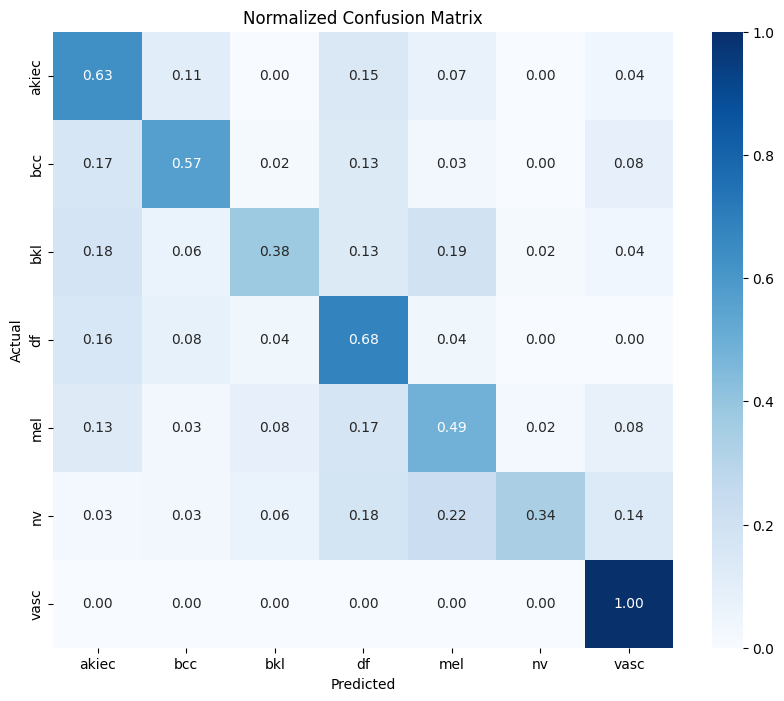

Confusion Matrix (normalized):
 [[0.62962963 0.11111111 0.         0.14814815 0.07407407 0.
  0.03703704]
 [0.16666667 0.56666667 0.01666667 0.13333333 0.03333333 0.
  0.08333333]
 [0.17741935 0.06451613 0.37634409 0.1344086  0.19354839 0.01612903
  0.03763441]
 [0.16       0.08       0.04       0.68       0.04       0.
  0.        ]
 [0.12707182 0.03314917 0.08287293 0.17127072 0.48618785 0.02209945
  0.07734807]
 [0.0259481  0.02794411 0.06387226 0.18063872 0.22355289 0.33932136
  0.13872255]
 [0.         0.         0.         0.         0.         0.
  1.        ]]
Classification Report:
               precision    recall  f1-score   support

       akiec       0.26      0.63      0.37        54
         bcc       0.39      0.57      0.46        60
         bkl       0.46      0.38      0.42       186
          df       0.06      0.68      0.12        25
         mel       0.25      0.49      0.33       181
          nv       0.98      0.34      0.50      1002
        vasc       0.0

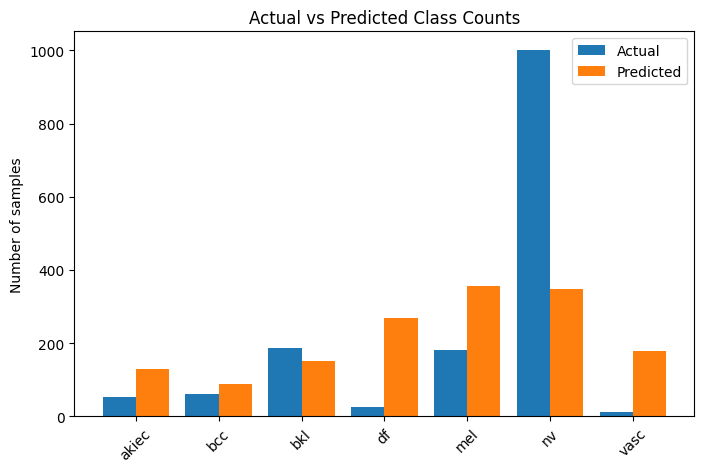

actual_counts: [  54   60  186   25  181 1002   11]
pred_counts: [130  88 151 270 355 347 178]


In [48]:
from utils import evaluate_model

# Load the pre-trained EfficientNet-B0 model
pretrained_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
pretrained_model.classifier[1] = nn.Linear(pretrained_model.classifier[1].in_features, 7)
pretrained_model = pretrained_model.to(device)

# Load the best model weights
pretrained_model.load_state_dict(torch.load("checkpoints/best_efficientnet_b0.pth", map_location=device))

# Create test DataLoader
BATCH_SIZE = 32
test_dataset = ImageDataset(X_test_tensor, y_test_tensor, transform=val_transform_efficience)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Evaluate the model on the test set
all_labels, all_preds = evaluate_model(pretrained_model, test_loader, device, le)

### Analysis of Results (Transfer Learning - EfficientNet)

At first glance, moving to a powerful, pre-trained model like EfficientNet did not yield the improvements we expected. In fact, **the overall accuracy dropped to 39%** (compared to 47% in our simple CNN). More importantly, we can see that the model's behavior changed drastically.

**Evaluating Malignant Classes (High Priority)**

For cancer detection, our main priority is Recall. Unfortunately, the EfficientNet model took a step backwards in this critical area:
- **Melanoma (mel)**: The Recall dropped significantly to 0.49 (down from 0.65 in the simple CNN). The model is now missing over half of the real melanoma cases. It is heavily confusing them with benign lesions like nv and bkl.
- **Basal Cell Carcinoma (bcc) & Actinic Keratoses (akiec)**: Both showed moderate Recall scores (0.57 and 0.63, respectively). While it catches a fair amount of these, the Precision remains very low, meaning it still generates many false alarms.

**The "Rare Class" Over-Compensation**

The most fascinating insight from this data is how the model treated the minority classes (df and vasc). Because EfficientNet is a very powerful feature extractor, and we forced it to look at these rare classes constantly using the Weighted Sampler, the model "over-learned" them:
- **Dermatofibroma (df)**: There were only 25 actual cases in the test set, but the model predicted df an astonishing 270 times. (Precision is a tiny 0.06).
- **Vascular lesions (vasc)**: There were only 11 actual cases, but the model predicted vasc 178 times.
The model became paranoid about these rare diseases.

**The Majority Class Problem (nv)**

The nv class (common moles) confirms this issue. Its Precision is 0.98, meaning when it finally predicts nv, it is highly accurate. However, its Recall has plummeted to 0.34. The model is terrified of classifying a image as a healthy mole, choosing instead to scatter its predictions across Melanoma, df, and vasc just to be safe.


**The Root Cause**: Why did an advanced model like EfficientNet fail so badly? The answer lies in how we handled the class imbalance. We accidentally applied "Double Dipping":

1. **Physical Balancing (Weighted Sampler)**: We generated new augmented images for the minority classes to equalize the dataset.

2. **Mathematical Balancing (Class Weights)**: We also used a *class_weights_tensor* inside the *CrossEntropyLoss* function.

By doing both, we accidentally gave the rarest class (vasc) a massive mathematical penalty. The model realized that making a mistake on vasc would result in a huge error score. To avoid this punishment, the neural network took a "lazy" shortcut: it simply predicted vasc for almost everything to minimize its mathematical loss, completely ignoring the visual features of the images.

To fix this, we are going to train a Version 2 (V2) of the EfficientNet model. Since our Data Augmentation strategy (flips, rotations, color jitter) is already doing a great job at physically balancing the dataset and providing visual variety, we will remove the class weights from the Loss Function.


In [49]:
criterion = nn.CrossEntropyLoss()

model = train_model(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    device=device,
    epochs=200,      # Max number of epochs
    patience=10,     # Early stopping
    save_path="checkpoints/best_efficientnet_b0_V2.pth"
)

Epoch 1/200 | Train Loss: 0.9555 Acc: 0.6515 | Val Loss: 1.0333 Acc: 0.6053
Epoch 2/200 | Train Loss: 0.8819 Acc: 0.6748 | Val Loss: 1.0450 Acc: 0.6112
Epoch 3/200 | Train Loss: 0.8702 Acc: 0.6825 | Val Loss: 1.0154 Acc: 0.6197
Epoch 4/200 | Train Loss: 0.8989 Acc: 0.6699 | Val Loss: 0.9929 Acc: 0.6263
Epoch 5/200 | Train Loss: 0.8850 Acc: 0.6767 | Val Loss: 1.0291 Acc: 0.6118
Epoch 6/200 | Train Loss: 0.9168 Acc: 0.6647 | Val Loss: 0.9921 Acc: 0.6276
Epoch 7/200 | Train Loss: 0.8800 Acc: 0.6807 | Val Loss: 0.9518 Acc: 0.6408
Epoch 8/200 | Train Loss: 0.8869 Acc: 0.6757 | Val Loss: 0.9631 Acc: 0.6382
Epoch 9/200 | Train Loss: 0.8831 Acc: 0.6745 | Val Loss: 1.0079 Acc: 0.6224
Epoch 10/200 | Train Loss: 0.8599 Acc: 0.6856 | Val Loss: 0.9851 Acc: 0.6289
Epoch 11/200 | Train Loss: 0.8870 Acc: 0.6760 | Val Loss: 0.9554 Acc: 0.6428
Epoch 12/200 | Train Loss: 0.8881 Acc: 0.6823 | Val Loss: 0.9568 Acc: 0.6421
Epoch 13/200 | Train Loss: 0.8790 Acc: 0.6776 | Val Loss: 0.9785 Acc: 0.6401
Epoch 14

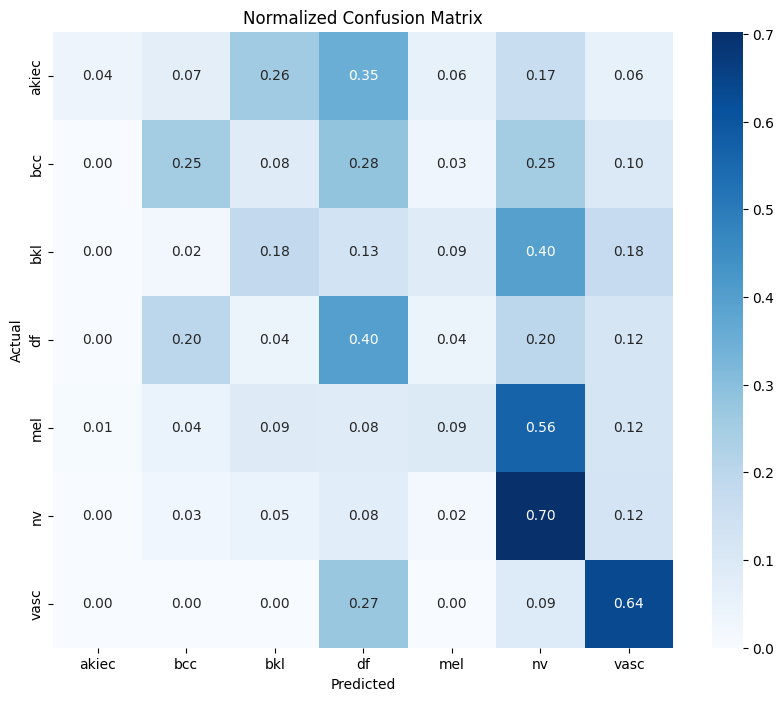

Confusion Matrix (normalized):
 [[0.03703704 0.07407407 0.25925926 0.35185185 0.05555556 0.16666667
  0.05555556]
 [0.         0.25       0.08333333 0.28333333 0.03333333 0.25
  0.1       ]
 [0.         0.02150538 0.1827957  0.1344086  0.08602151 0.39784946
  0.17741935]
 [0.         0.2        0.04       0.4        0.04       0.2
  0.12      ]
 [0.00552486 0.0441989  0.08839779 0.08287293 0.09392265 0.56353591
  0.12154696]
 [0.00199601 0.0259481  0.0489022  0.07784431 0.01896208 0.70259481
  0.1237525 ]
 [0.         0.         0.         0.27272727 0.         0.09090909
  0.63636364]]
Classification Report:
               precision    recall  f1-score   support

       akiec       0.40      0.04      0.07        54
         bcc       0.24      0.25      0.25        60
         bkl       0.29      0.18      0.22       186
          df       0.06      0.40      0.10        25
         mel       0.29      0.09      0.14       181
          nv       0.77      0.70      0.74      1002
   

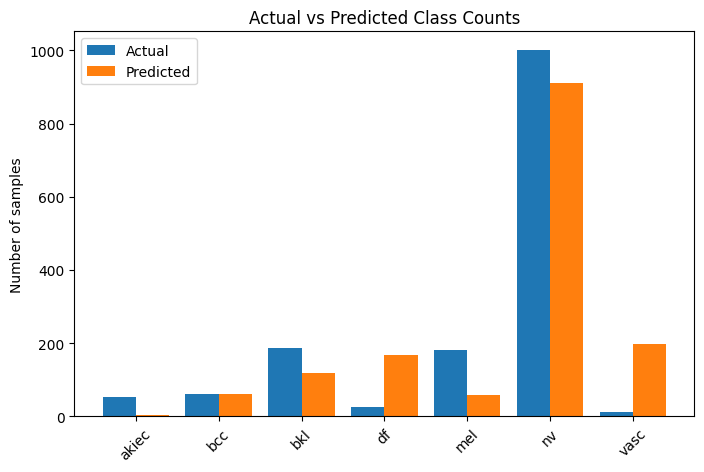

actual_counts: [  54   60  186   25  181 1002   11]
pred_counts: [  5  62 119 167  58 910 198]


In [50]:
from utils import evaluate_model

# Load the pre-trained EfficientNet-B0 model
pretrained_model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
pretrained_model.classifier[1] = nn.Linear(pretrained_model.classifier[1].in_features, 7)
pretrained_model = pretrained_model.to(device)

# Load the best model weights
pretrained_model.load_state_dict(torch.load("checkpoints/best_efficientnet_b0_V2.pth", map_location=device))

# Create test DataLoader
BATCH_SIZE = 32
test_dataset = ImageDataset(X_test_tensor, y_test_tensor, transform=val_transform)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Evaluate the model on the test set
all_labels, all_preds = evaluate_model(pretrained_model, test_loader, device, le)

In our first EfficientNet attempt (V1), using both Class Weights and a Weighted Sampler caused a massive over-compensation towards the rarest classes. For this Version 2 (V2), we removed the Class Weights to rely solely on the data.

While the overall Accuracy improved slightly to 52%, **the clinical value of the model collapsed**. It almost completely lost its ability to detect cancer. The model is failing to learn meaningful clinical features and is instead using two "lazy" fallback strategies for images it doesn't understand:
- **The "Safe" Fallback (nv)**: For most images that look like standard skin lesions, the model defaults to the majority class (nv) because statistically, it's the safest guess.
- **The "Garbage Bin" Fallback (vasc and df)**: The dataset only contains 11 actual vasc images and 25 df images. Yet, the model predicted vasc 198 times and df 167 times. As we applied heavy Data Augmentation (flips, crops, color jitters) to a tiny pool of base images, the model likely learned to associate these labels with "distorted/noisy pixels" rather than actual vascular pathology. Consequently, whenever the model is confused by a difficult image from any other class, it simply dumps it into these categories.

**Conclusion**: Our experiments with EfficientNet using purely images have reached a dead end. We have proven that simply showing the model more (and heavily distorted) images is not enough to teach it the subtle visual differences between a dangerous Melanoma and a common mole. The model has hit a "visual ceiling." This limitation perfectly mimics real-world dermatology, where doctors rarely diagnose based on pixels alone. To break these visual ties and stop the model from guessing, we must upgrade to a **Multimodal Architecture**. By feeding the model clinical metadata (patient age, sex, and lesion location) alongside the image, we will provide the critical context needed to accurately diagnose these highly similar skin diseases.

## Multi-modal CNN (Images + Metadata)

In clinical dermatology, a diagnosis is rarely made based on an image alone; doctors also consider the patient's age, sex, and the location of the lesion. To mimic this professional approach, we move from a single-input model to a Multi-Modal architecture.

Before integrating complex backbones like EfficientNet, we have implemented a **custom Multi-Modal CNN**. This serves as a critical Proof of Concept for several reasons:
- **Feature Fusion Baseline**: It allows us to establish a clear benchmark of how metadata (age, sex, anatomical site) interacts with spatial features from the image.
- **Controlled Experimentation**: A simpler architecture makes it easier to debug the "fusion" point.
- **Justification for Complexity**: By starting here, we can quantitatively prove if adding metadata actually improves the model. This provides a solid justification before moving to more computationally expensive models like Multi-Modal EfficientNet-B0.

**Architecture Strategy**

The model consists of two branches:
- **Image Branch**: A convolutional pipeline to extract visual patterns.
- **Metadata Branch**: A Multi-Layer Perceptron (MLP) to process categorical and numerical patient data.

Both branches are concatenated into a final "feature vector" that the model uses to make the final diagnostic prediction.

In [51]:
print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU available: True
GPU name: NVIDIA GeForce RTX 5060 Ti


As we did before, it is important to create a class to wrap the images, labels and, in this case, metadata so PyTorch can work with them easily. It is the same that `ImageDataset` but adding the metadata.

In [52]:
class MultiModalDataset(Dataset):
    def __init__(self, images, meta, labels, transform=None):
        """
        images: image tensor (N, C, H, W)
        meta: metadata tensor (N, num_features)
        labels: class labels tensor (N,)
        transform: image transformations (data augmentation) to apply on the images
        """
        self.images = images
        self.meta = meta
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = self.images[idx]
        meta = self.meta[idx]
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, meta, label

To ensure a fair and reliable comparison between our previous image-only models and this enriched metadata architecture, we have kept the core training hyperparameters constant.

However, unlike our previous dataset class, this one is designed to handle heterogeneous data  with `MultiModalDataset`. It simultaneously fetches the image tensor and the corresponding metadata vector (age, sex, location) for each sample.

We also  continue applying `train_transform_fn` only to the training images. The metadata remains untouched by these visual augmentations, ensuring the patient information stays accurate while the image variety helps the model generalize.

In [53]:
BATCH_SIZE = 32

train_dataset = MultiModalDataset(
    X_train_tensor, X_train_meta_tensor, y_train_tensor, transform=train_transform_fn
)

val_dataset = MultiModalDataset(
    X_val_tensor, X_val_meta_tensor, y_val_tensor, transform=val_transform
)

Even though we are now providing the model with extra patient information (metadata), the underlying dataset remains highly imbalanced. To prevent the model from becoming biased towards common cases like *mel*, we implement a **Weighted Sampling strategy**.

It is similar than what we did before. Instead of a standard random shuffle, the sampler uses the pre-calculated *sample_weights* to pick images for each batch. This means that in every training step, the model is exposed to an equal distribution of all 7 lesion types.

In [54]:
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

In [55]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

Now, we are going to initialize the MultiModalSimpleCNN. The key innovation here is the dual-stream architecture: while the convolutional layers process the visual patterns, a parallel fully connected network processes the patient's demographic data.

In [56]:
from models.multimodal_cnn import MultiModalSimpleCNN

device = "cuda" if torch.cuda.is_available() else "cpu"

# Get the number of metadata features to pass to the model
meta_input_dim = X_train_meta_tensor.shape[1]
model = MultiModalSimpleCNN(input_channels=3, meta_input_dim=meta_input_dim, num_classes=7, dropout_rate=0.5).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

We also set the same loss function and optimizer.

In [57]:
# Same training function as before
from utils import train_model

trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=200,
    patience=10,
    save_path="checkpoints/best_multimodal_simple_cnn.pth"
)

Epoch 1/200 | Train Loss: 1.1943 Acc: 0.2914 | Val Loss: 3.2450 Acc: 0.0914
Epoch 2/200 | Train Loss: 0.8920 Acc: 0.3911 | Val Loss: 2.7513 Acc: 0.1480
Epoch 3/200 | Train Loss: 0.7809 Acc: 0.4498 | Val Loss: 3.1819 Acc: 0.1401
Epoch 4/200 | Train Loss: 0.6830 Acc: 0.4723 | Val Loss: 2.8650 Acc: 0.1434
Epoch 5/200 | Train Loss: 0.6527 Acc: 0.4992 | Val Loss: 2.5809 Acc: 0.2125
Epoch 6/200 | Train Loss: 0.6285 Acc: 0.5116 | Val Loss: 2.5904 Acc: 0.1908
Epoch 7/200 | Train Loss: 0.5640 Acc: 0.5417 | Val Loss: 2.3727 Acc: 0.2724
Epoch 8/200 | Train Loss: 0.5428 Acc: 0.5544 | Val Loss: 2.3553 Acc: 0.2546
Epoch 9/200 | Train Loss: 0.5024 Acc: 0.5687 | Val Loss: 2.4237 Acc: 0.2586
Epoch 10/200 | Train Loss: 0.5100 Acc: 0.5606 | Val Loss: 2.3853 Acc: 0.2395
Epoch 11/200 | Train Loss: 0.4715 Acc: 0.5729 | Val Loss: 1.9235 Acc: 0.3724
Epoch 12/200 | Train Loss: 0.4388 Acc: 0.5982 | Val Loss: 2.1236 Acc: 0.3112
Epoch 13/200 | Train Loss: 0.4220 Acc: 0.6099 | Val Loss: 2.3140 Acc: 0.2842
Epoch 14

And to finish, we are going to evaluate the model.

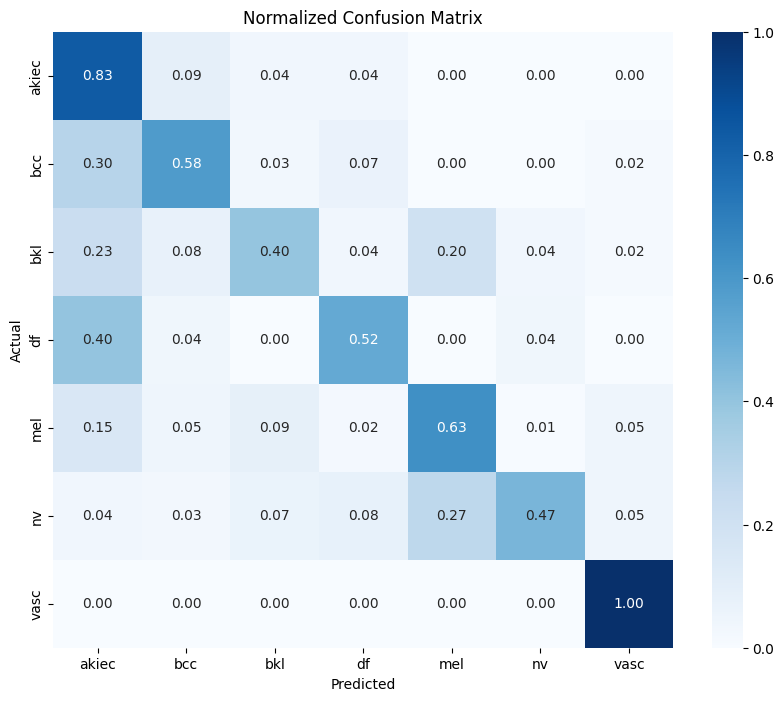

Confusion Matrix (normalized):
 [[0.83333333 0.09259259 0.03703704 0.03703704 0.         0.
  0.        ]
 [0.3        0.58333333 0.03333333 0.06666667 0.         0.
  0.01666667]
 [0.2311828  0.07526882 0.39784946 0.03763441 0.20430108 0.03763441
  0.01612903]
 [0.4        0.04       0.         0.52       0.         0.04
  0.        ]
 [0.15469613 0.04972376 0.08839779 0.02209945 0.62983425 0.00552486
  0.04972376]
 [0.03792415 0.02894212 0.06586826 0.07984032 0.27345309 0.46706587
  0.04690619]
 [0.         0.         0.         0.         0.         0.
  1.        ]]
Classification Report:
               precision    recall  f1-score   support

       akiec       0.25      0.83      0.38        54
         bcc       0.38      0.58      0.46        60
         bkl       0.46      0.40      0.43       186
          df       0.12      0.52      0.19        25
         mel       0.27      0.63      0.38       181
          nv       0.98      0.47      0.63      1002
        vasc       0

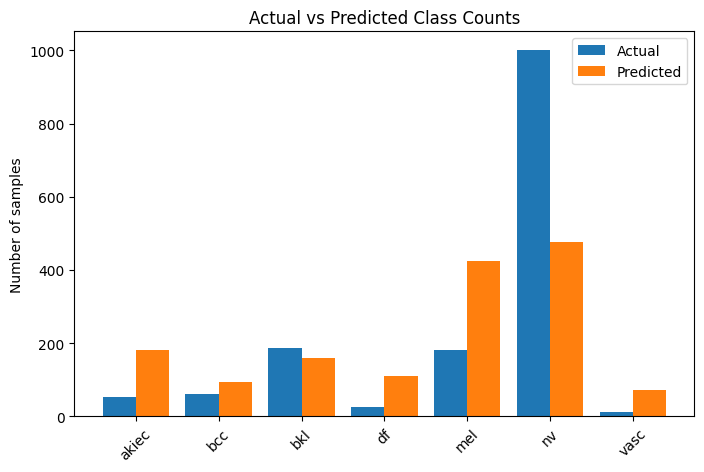

actual_counts: [  54   60  186   25  181 1002   11]
pred_counts: [182  93 160 110 426 477  71]


In [58]:
from utils import evaluate_model

# Create a new instance of the model and load the best weights
multimodal_model = MultiModalSimpleCNN(
    input_channels=3,
    meta_input_dim=meta_input_dim,
    num_classes=7, dropout_rate=0.5
    ).to(device)

multimodal_model.load_state_dict(
    torch.load("checkpoints/best_multimodal_simple_cnn.pth", map_location=device)
    )

# Create test DataLoader
BATCH_SIZE = 32
test_dataset  = MultiModalDataset(X_test_tensor, X_test_meta_tensor, y_test_tensor, transform=val_transform)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Evaluate the model on the test set
all_labels, all_preds = evaluate_model(multimodal_model, test_loader, device, le)

### Multimodal Model Evaluation

After the disastrous "Mode Collapse" we experienced with the image-only EfficientNet, we returned to our baseline CNN architecture. But this time, we gave the model a crucial upgrade: Multimodal Learning. By feeding the network clinical metadata (patient age, sex, and anatomical location) alongside the images, we aimed to give it the context doctors use to break visual ties.

The results show a clear step in the right direction. The overall accuracy improved to 50% (up from 47% in the image-only CNN and 39% in the EfficientNet), but more importantly, the model regained its clinical utility.

**Evaluating Malignant Classes (High Priority)**

The addition of metadata proved highly effective for identifying specific cancers:
- **Actinic Keratoses (akiec)**: The model achieved an outstanding Recall of 0.83. This is a massive leap from the 0.37 and 0.04 we saw in previous models. Since akiec often appears on specific body parts of older patients (like the face or scalp due to sun exposure), the metadata clearly gave the model the context it needed to flag these pre-cancerous lesions.
- **Melanoma (mel) and Basal Cell Carcinoma (bcc)**: The model maintained its "safety first" approach. It successfully caught 63% of Melanomas and 58% of BCCs. While it still generates false positives (low Precision), it is acting like a cautious screening tool rather than randomly guessing.

**The Impact on Benign and Rare Classes**

The metadata successfully cured the "Garbage Bin" effect we saw in the EfficientNet:
- **Vascular Lesions (vasc)**: The metadata successfully put a "leash" on the model's hallucinations. Instead of dumping hundreds of confusing images into the vasc category (as the image-only model did), it reduced its predictions to 71. While the model is still acting "paranoid" (generating 60 false positives for the 11 actual cases), catching 100% of them proves that the metadata is helping the model establish much stricter boundaries for rare diseases.
- **The Majority Class (nv)**: The Recall for healthy moles (nv) improved to 0.47 (up from 0.42 in the baseline CNN). While it still heavily confuses healthy moles with Melanoma, it is slowly learning to separate them.

**Conclusion**: The Multimodal CNN proves our core hypothesis: pixels alone are not enough, and clinical context matters. By adding just three pieces of patient data (age, sex, location), the simple CNN outperformed the massive, mathematically complex EfficientNet.
However, we are still hitting a ceiling. While the metadata provides great context, the basic CNN architecture simply lacks the deep visual extraction power needed to significantly reduce the false alarm rate (Precision). The logical, final step of our project is now clear: we must combine the deep visual intelligence of advanced models (EfficientNet or ViT) with the clinical context of the Multimodal approach.

## Multi-modal + Pre-trained CNN

Having established a baseline with the custom Multi-Modal CNN, we now move to our most advanced convolutional strategy. This architecture combines the superior feature extraction of a **pre-trained EfficientNet-B0 with the contextual clinical data of the patient**.

In [ ]:
from models.multiModalEfficientNet import MultiModalEfficientNet

device = "cuda" if torch.cuda.is_available() else "cpu"

num_classes = 7
# Get the number of metadata features to pass to the model
meta_input_dim = X_train_meta_tensor.shape[1]

# Create the multimodal model that combines EfficientNet-B0 for images and a simple MLP for metadata
model = MultiModalEfficientNet(meta_input_dim, num_classes).to(device)

# Freeze EfficientNet features if you want progressive fine-tuning
for param in model.cnn.features.parameters():
    param.requires_grad = False

To successfully train our most advanced architecture, we must ensure that the data pipeline satisfies both the multimodal structure and the EfficientNet requirements.
- **Format and Distribution**: As with our previous pre-trained experiment, we apply the specific ImageNet normalization and $224 \times 224$ resizing. This ensures the visual branch of our multimodal model receives data in the exact distribution it was originally optimized for.
- **Unified Container**: We use the `MultiModalDataset` to bundle these high-resolution images with their corresponding patient metadata. This allows the model to receive a "complete clinical picture" in every single batch.
- **Consistency**: By maintaining a `BATCH_SIZE = 32`, we keep the training dynamics consistent with our baseline, ensuring that any performance gains can be directly attributed to the model's increased complexity and pre-trained knowledge.

In [60]:
BATCH_SIZE = 32

train_dataset_multi = MultiModalDataset(
    X_train_tensor, X_train_meta_tensor, y_train_tensor, 
    transform=train_transform_efficience
)

val_dataset_multi = MultiModalDataset(
    X_val_tensor, X_val_meta_tensor, y_val_tensor, 
    transform=val_transform_efficience
)

In [61]:
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

In [62]:
train_loader_multi = DataLoader(train_dataset_multi, batch_size=BATCH_SIZE, sampler=sampler)
val_loader_multi = DataLoader(val_dataset_multi, batch_size=BATCH_SIZE, shuffle=False)

We follow the same loss function and optimizer.

In [ ]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.Adam(model.parameters(), lr=1e-4)

And the same training function.

In [ ]:
model = train_model(
    model=model,
    train_loader=train_loader_multi,
    val_loader=val_loader_multi,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=200,
    patience=10,
    save_path="checkpoints/best_multimodal_efficientnet.pth"
)

Epoch 1/200 | Train Loss: 1.4055 Acc: 0.2534 | Val Loss: 3.2166 Acc: 0.0513
Epoch 2/200 | Train Loss: 0.9640 Acc: 0.3532 | Val Loss: 3.2221 Acc: 0.0789
Epoch 3/200 | Train Loss: 0.8024 Acc: 0.4134 | Val Loss: 3.2113 Acc: 0.1184
Epoch 4/200 | Train Loss: 0.6956 Acc: 0.4658 | Val Loss: 3.0908 Acc: 0.1250
Epoch 5/200 | Train Loss: 0.6568 Acc: 0.4787 | Val Loss: 2.9030 Acc: 0.1421
Epoch 6/200 | Train Loss: 0.6008 Acc: 0.5069 | Val Loss: 2.8568 Acc: 0.1586
Epoch 7/200 | Train Loss: 0.5882 Acc: 0.5228 | Val Loss: 2.7049 Acc: 0.1638
Epoch 8/200 | Train Loss: 0.5287 Acc: 0.5443 | Val Loss: 2.6439 Acc: 0.1704
Epoch 9/200 | Train Loss: 0.5148 Acc: 0.5457 | Val Loss: 2.6443 Acc: 0.1638
Epoch 10/200 | Train Loss: 0.5100 Acc: 0.5528 | Val Loss: 2.5283 Acc: 0.1724
Epoch 11/200 | Train Loss: 0.4848 Acc: 0.5585 | Val Loss: 2.3709 Acc: 0.1875
Epoch 12/200 | Train Loss: 0.4777 Acc: 0.5664 | Val Loss: 2.5079 Acc: 0.1809
Epoch 13/200 | Train Loss: 0.4737 Acc: 0.5716 | Val Loss: 2.4412 Acc: 0.1947
Epoch 14

Now, we will check the performance.

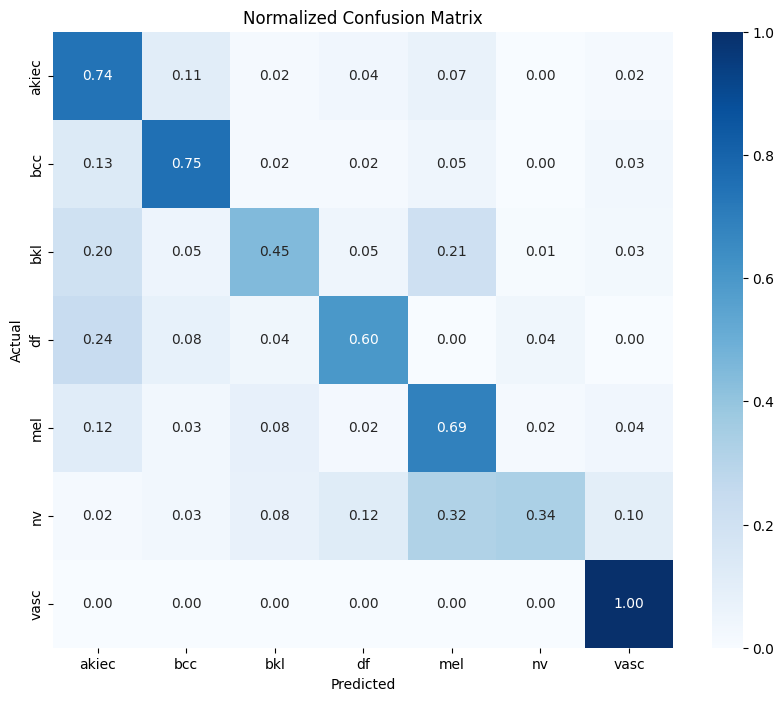

Confusion Matrix (normalized):
 [[0.74074074 0.11111111 0.01851852 0.03703704 0.07407407 0.
  0.01851852]
 [0.13333333 0.75       0.01666667 0.01666667 0.05       0.
  0.03333333]
 [0.20430108 0.05376344 0.44623656 0.0483871  0.20967742 0.01075269
  0.02688172]
 [0.24       0.08       0.04       0.6        0.         0.04
  0.        ]
 [0.1160221  0.03314917 0.08287293 0.02209945 0.69060773 0.01657459
  0.03867403]
 [0.01596806 0.03193613 0.07684631 0.11876248 0.31836327 0.33532934
  0.10279441]
 [0.         0.         0.         0.         0.         0.
  1.        ]]
Classification Report:
               precision    recall  f1-score   support

       akiec       0.31      0.74      0.44        54
         bcc       0.45      0.75      0.56        60
         bkl       0.47      0.45      0.46       186
          df       0.10      0.60      0.17        25
         mel       0.26      0.69      0.37       181
          nv       0.98      0.34      0.50      1002
        vasc       0

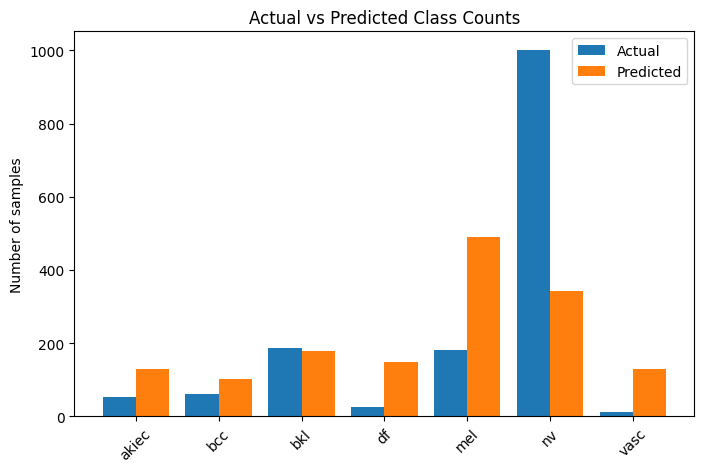

actual_counts: [  54   60  186   25  181 1002   11]
pred_counts: [129 101 178 150 490 342 129]


In [65]:
from utils import evaluate_model

# Create a new instance of the model and load the best weights
model_eval = MultiModalEfficientNet(meta_input_dim, num_classes).to(device)
model_eval.load_state_dict(torch.load("checkpoints/best_multimodal_efficientnet.pth", map_location=device))

# Create test DataLoader
test_dataset = MultiModalDataset(
    X_test_tensor, 
    X_test_meta_tensor, 
    y_test_tensor, 
    transform=val_transform_efficience # <--- Consistente con 224x224
)

test_loader_multi = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)
# Evaluate the model on the test set

all_labels, all_preds = evaluate_model(model_eval, test_loader_multi, device, le)

### Multimodal + Pre-Trained Model Evaluation

After seeing how metadata improved our baseline CNN, we finally combined the heavy-duty visual power of EfficientNet with clinical metadata. The result is a model that is **incredibly "paranoid" in a clinical sense**, it is terrified of missing a single case of disease.

While the overall accuracy dropped to 43% (due to the difficulty of managing the massive nv class), the model’s ability to "catch" diseases reached levels we haven't seen before.

**Evaluating Malignant Classes**
The combination of EfficientNet’s deep feature extraction and metadata created a powerful screening effect:
- **Actinic Keratoses (akiec) and Basal Cell Carcinoma (bcc)**: The model is now catching 74% and 75% of these cases respectively. These are very strong Recall numbers. It means the model is successfully using the "visual intelligence" of EfficientNet to identify the subtle textures of these cancers.
- **Melanoma (mel)**: The Recall jumped to 0.69. For a disease as dangerous as Melanoma, catching nearly 70% of cases is a significant clinical milestone, even if it comes with many false alarms.

**The "Rare Class" Phenomenon**
- **Vascular Lesions (vasc)**: We achieved a perfect Recall of 1.00. The model did not miss a single vascular lesion. However, when we look at the pred_counts, we can see that it predicted 129 cases when there were only 11. It is over-predicting the rare classes significantly, but in medicine, a "false alarm" is often preferred over a "missed cancer."
- **Dermatofibroma (df)**: Similar to others, it caught 60% of these rare lesions, proving that the multimodal approach prevents these small classes from being completely ignored by the network.

**The "Nevus" Confusion**

The biggest hit to our accuracy comes from the Nevus (nv) class. The Recall for healthy moles dropped to 0.34. Our hypothesis is that as EfficientNet is so good at finding complex patterns, it is finding "suspicious" features in healthy moles that a simpler CNN ignored. It is essentially "over-analyzing" the images. This is why the Precision for almost every other class is low—thousands of healthy moles are being reclassified as potentially dangerous.

**Conclusion**: The Multimodal EfficientNet is our most aggressive model yet. It has solved the "Mode Collapse" completely and turned into a highly sensitive screening tool. It behaves like a medical student who has read every textbook: it sees potential danger everywhere. However, it is currently too "anxious." We suspect this is because we are giving the model a double incentive to focus on rare classes: first through clinical metadata and second through Class Weights in our loss function. To fix this, we are going to replicate the experiment we did with the simple EfficientNet, we will remove the Class Weights from the Criterion.


In [77]:
criterion = nn.CrossEntropyLoss()

model = train_model(
    model=model,
    train_loader=train_loader_multi,
    val_loader=val_loader_multi,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=200,
    patience=10,
    save_path="checkpoints/best_multimodal_efficientnet_V2.pth"
)

Epoch 1/200 | Train Loss: 0.4138 Acc: 0.8550 | Val Loss: 1.1986 Acc: 0.5888
Epoch 2/200 | Train Loss: 0.4248 Acc: 0.8519 | Val Loss: 1.1986 Acc: 0.5888
Epoch 3/200 | Train Loss: 0.4268 Acc: 0.8573 | Val Loss: 1.1986 Acc: 0.5888
Epoch 4/200 | Train Loss: 0.3985 Acc: 0.8571 | Val Loss: 1.1986 Acc: 0.5888
Epoch 5/200 | Train Loss: 0.4158 Acc: 0.8530 | Val Loss: 1.1986 Acc: 0.5888
Epoch 6/200 | Train Loss: 0.4197 Acc: 0.8471 | Val Loss: 1.1986 Acc: 0.5888
Epoch 7/200 | Train Loss: 0.4103 Acc: 0.8630 | Val Loss: 1.1986 Acc: 0.5888
Epoch 8/200 | Train Loss: 0.4101 Acc: 0.8579 | Val Loss: 1.1986 Acc: 0.5888
Epoch 9/200 | Train Loss: 0.4271 Acc: 0.8529 | Val Loss: 1.1986 Acc: 0.5888
Epoch 10/200 | Train Loss: 0.4326 Acc: 0.8462 | Val Loss: 1.1986 Acc: 0.5888
Epoch 11/200 | Train Loss: 0.4233 Acc: 0.8517 | Val Loss: 1.1986 Acc: 0.5888
Early stopping triggered after 11 epochs.


## Pre-Trained ViT

After testing CNNs, we are moving to the most advanced architecture: the Vision Transformer (ViT). In this final experiment, we combine the power of Transformers with patient metadata.

**Why use ViT?**
- **Global Attention**: Unlike CNNs, which look at images "pixel by pixel" (convolutions), ViT uses Self-Attention. This allows the model to look at the entire image at once and understand how different parts of a lesion relate to each other.
- **Higher Capacity**: ViT is a more "expressive" model. We want to see if this extra power helps the model distinguish between skin diseases that look very similar.
- **Data Fusion**: Just like before, we mix the global vision of the Transformer with the patient's age and sex to get the most complete diagnosis possible.

**The  goal**: To see if the Attention mechanism of the ViT performs better than the Convolutions of EfficientNet when using multimodal data, especially for improving the F1-Score in difficult classes.

While ViT is a state-of-the-art architecture, it has a potential weakness for our project: **it usually requires massive amounts of data to perform well**. As we only have 10.000 images in the HAM10000 dataset, there is a risk that the **ViT might not learn as efficiently as other architecture**.

In [66]:
from models.multiModalViT import MultiModalViT

device = "cuda" if torch.cuda.is_available() else "cpu"

num_classes = 7
meta_input_dim = X_train_meta_tensor.shape[1]  # Number of metadata features

# Create the multimodal model that combines a ViT for images and a simple MLP for metadata
model = MultiModalViT(meta_input_dim, num_classes).to(device)


# Freeze ViT layers to prevent overfitting and speed up training
for param in model.vit.parameters():
    param.requires_grad = False

Just like with EfficientNet, we must adapt our images to the specific requirements of the Vision Transformer. However, for ViT, this is even more critical because the model processes images as a sequence of fixed-size patches.
- **Resolution ($224 \times 224$)**: The ViT architecture expects this exact size to correctly divide the image into $16 \times 16$ patches. If the resolution is off, the spatial relationship between these patches changes, and the pre-trained weights won't work correctly.
- **Standardized Normalization**: We continue using the ImageNet mean and standard deviation to ensure the pixel values match the distribution the Transformer saw during its massive pre-training phase.
- **Augmentation Strategy**: We maintain our RandomOneOrMoreAugment to keep the experiment fair, but now applying it to the higher resolution needed for this architecture.

In [67]:
train_transform_vit = transforms.Compose([
    transforms.ToPILImage(),
    RandomOneOrMoreAugment(augmentation_candidates_pre_trained), 
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform_vit = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

To ensure a fair and reliable comparison between the previous models and the Vision Transformer, we maintain the same data loading strategy.

- **Constant Batch Size**: We keep BATCH_SIZE = 32. This is especially important for ViT, as the self-attention mechanism's stability can be sensitive to batch dynamics.- **Balanced Sampling**: We continue using the `WeightedRandomSampler`. Since ViT is "data-hungry," it is vital that every batch contains a balanced representation of all 7 lesion types to prevent the model from ignoring minority classes.
- **Multimodal Integration**: The `MultiModalDataset` now feeds the $224 \times 224$ images (the resolution ViT needs) along with the patient metadata, keeping the input structure consistent with our previous multimodal experiments.

In [68]:
BATCH_SIZE = 32

train_dataset_vit = MultiModalDataset(
    X_train_tensor, X_train_meta_tensor, y_train_tensor, transform=train_transform_vit
    )

val_dataset_vit   = MultiModalDataset(
    X_val_tensor, X_val_meta_tensor, y_val_tensor, transform=val_transform_vit
    )



In [69]:
sampler = WeightedRandomSampler(
    weights=sample_weights, 
    num_samples=len(sample_weights), 
    replacement=True
)

In [70]:
train_loader_multi_vit = DataLoader(train_dataset_vit, batch_size=BATCH_SIZE, sampler=sampler)
val_loader_multi_vit = DataLoader(val_dataset_vit, batch_size=BATCH_SIZE, shuffle=False)

We follow the same loss function and optimizer.

In [71]:
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))
optimizer = optim.AdamW(model.parameters(), lr=1e-4)

And the same training function.

In [72]:
from utils import train_model

model = train_model(
    model=model,
    train_loader=train_loader_multi_vit,
    val_loader=val_loader_multi_vit,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=200,
    patience=10,
    save_path="checkpoints/best_multimodal_vit.pth"
)

Epoch 1/200 | Train Loss: 1.1497 Acc: 0.3116 | Val Loss: 3.4783 Acc: 0.0539
Epoch 2/200 | Train Loss: 0.7040 Acc: 0.4384 | Val Loss: 3.2314 Acc: 0.1007
Epoch 3/200 | Train Loss: 0.5812 Acc: 0.4970 | Val Loss: 2.8555 Acc: 0.1224
Epoch 4/200 | Train Loss: 0.5113 Acc: 0.5244 | Val Loss: 2.6617 Acc: 0.1263
Epoch 5/200 | Train Loss: 0.4544 Acc: 0.5551 | Val Loss: 2.5117 Acc: 0.1421
Epoch 6/200 | Train Loss: 0.4206 Acc: 0.5773 | Val Loss: 2.3486 Acc: 0.1651
Epoch 7/200 | Train Loss: 0.3803 Acc: 0.5984 | Val Loss: 2.1242 Acc: 0.2191
Epoch 8/200 | Train Loss: 0.3566 Acc: 0.6238 | Val Loss: 2.0050 Acc: 0.2612
Epoch 9/200 | Train Loss: 0.3393 Acc: 0.6423 | Val Loss: 1.9270 Acc: 0.2888
Epoch 10/200 | Train Loss: 0.3130 Acc: 0.6567 | Val Loss: 1.9851 Acc: 0.2803
Epoch 11/200 | Train Loss: 0.3116 Acc: 0.6664 | Val Loss: 1.9533 Acc: 0.3020
Epoch 12/200 | Train Loss: 0.2970 Acc: 0.6729 | Val Loss: 1.7448 Acc: 0.3757
Epoch 13/200 | Train Loss: 0.2789 Acc: 0.6885 | Val Loss: 1.7625 Acc: 0.3737
Epoch 14

Now, we will check the performance.

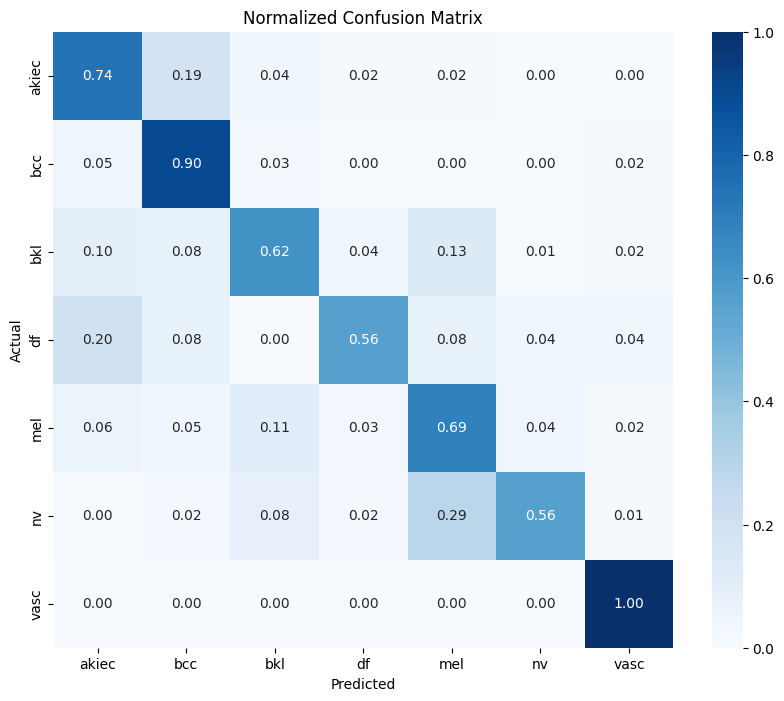

Confusion Matrix (normalized):
 [[0.74074074 0.18518519 0.03703704 0.01851852 0.01851852 0.
  0.        ]
 [0.05       0.9        0.03333333 0.         0.         0.
  0.01666667]
 [0.09677419 0.08064516 0.62365591 0.03763441 0.1344086  0.01075269
  0.01612903]
 [0.2        0.08       0.         0.56       0.08       0.04
  0.04      ]
 [0.05524862 0.04972376 0.11049724 0.03314917 0.69060773 0.0441989
  0.01657459]
 [0.00399202 0.02295409 0.08383234 0.0239521  0.28842315 0.56487026
  0.01197605]
 [0.         0.         0.         0.         0.         0.
  1.        ]]
Classification Report:
               precision    recall  f1-score   support

       akiec       0.50      0.74      0.60        54
         bcc       0.48      0.90      0.62        60
         bkl       0.52      0.62      0.57       186
          df       0.27      0.56      0.36        25
         mel       0.28      0.69      0.40       181
          nv       0.98      0.56      0.72      1002
        vasc       0.

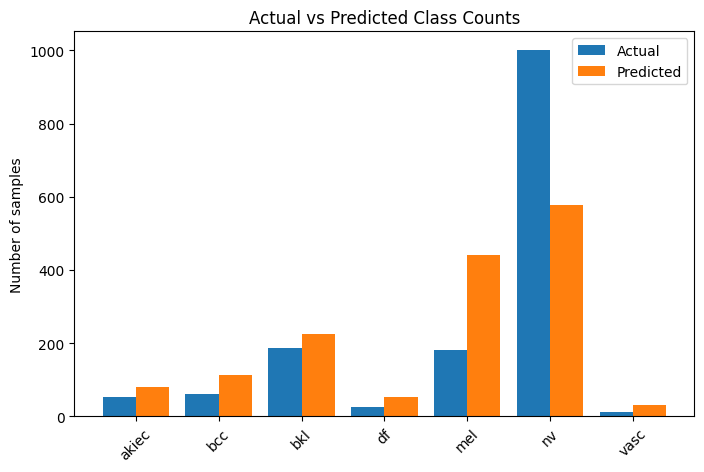

actual_counts: [  54   60  186   25  181 1002   11]
pred_counts: [ 80 113 224  52 442 577  31]


In [73]:
from utils import evaluate_model

# Create a new instance of the model and load the best weights
model = MultiModalViT(meta_input_dim, num_classes).to(device)
model.load_state_dict(torch.load("checkpoints/best_multimodal_vit.pth", map_location=device))

# Create test DataLoader
BATCH_SIZE = 32
test_dataset  = MultiModalDataset(X_test_tensor, X_test_meta_tensor, y_test_tensor, transform=val_transform_vit)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# Evaluate the model on the test set
all_labels, all_preds = evaluate_model(model, test_loader, device, le)

### Pre-Trained ViT Model Evaluation

Overall, the Multimodal ViT is a huge success. It is the first model to cross the 60% accuracy mark and it shows a much more "professional" behavior with the minority classes. However, when we look closer at the most critical classes, we see that the battle isn't over.

**High Intelligence**

The model is no longer guessing. A Recall of 0.90 for BCC and 0.74 for AKIEC proves that the **ViT has truly learned the visual patterns of these cancers**. It is much more stable than the EfficientNet and doesn't "panic" as easily with rare diseases like vasc.

**The "Mel" Problem**
Despite the high accuracy, the Melanoma (mel) class is still causing trouble:
- The model is still predicting 442 cases of Melanoma when there are only 181.
- This tells us that even with the "Global Attention" of the Transformer, the model is still too aggressive. It is still sacrificing too many healthy moles (nv) to ensure it catches the Melanomas.

**The possible solution: Removing the Weights**
As the ViT is already so good at identifying features, we believe the Class Weights in the criterion are now doing more harm than good. They are forcing this highly capable model to be "paranoid."

In [ ]:
model = MultiModalViT(meta_input_dim, num_classes).to(device)

for param in model.vit.parameters():
    param.requires_grad = False
    

optimizer = optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

In [85]:
model = train_model(
    model=model,
    train_loader=train_loader_multi_vit,
    val_loader=val_loader_multi_vit,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=200,
    patience=10,
    save_path="checkpoints/best_multimodal_vit_V2.pth"
)

Epoch 1/200 | Train Loss: 1.5565 Acc: 0.4499 | Val Loss: 1.2355 Acc: 0.6026
Epoch 2/200 | Train Loss: 1.1226 Acc: 0.6054 | Val Loss: 1.0688 Acc: 0.6230
Epoch 3/200 | Train Loss: 0.9906 Acc: 0.6546 | Val Loss: 0.9513 Acc: 0.6717
Epoch 4/200 | Train Loss: 0.8892 Acc: 0.6823 | Val Loss: 1.0928 Acc: 0.6079
Epoch 5/200 | Train Loss: 0.8229 Acc: 0.7024 | Val Loss: 0.9303 Acc: 0.6632
Epoch 6/200 | Train Loss: 0.7871 Acc: 0.7120 | Val Loss: 0.8775 Acc: 0.6796
Epoch 7/200 | Train Loss: 0.7410 Acc: 0.7400 | Val Loss: 0.7778 Acc: 0.7132
Epoch 8/200 | Train Loss: 0.7111 Acc: 0.7406 | Val Loss: 0.8165 Acc: 0.6901
Epoch 9/200 | Train Loss: 0.6920 Acc: 0.7472 | Val Loss: 0.9043 Acc: 0.6664
Epoch 10/200 | Train Loss: 0.6682 Acc: 0.7595 | Val Loss: 0.8306 Acc: 0.6868
Epoch 11/200 | Train Loss: 0.6431 Acc: 0.7657 | Val Loss: 0.8070 Acc: 0.6941
Epoch 12/200 | Train Loss: 0.6276 Acc: 0.7638 | Val Loss: 0.7955 Acc: 0.6961
Epoch 13/200 | Train Loss: 0.5925 Acc: 0.7819 | Val Loss: 0.7674 Acc: 0.7105
Epoch 14

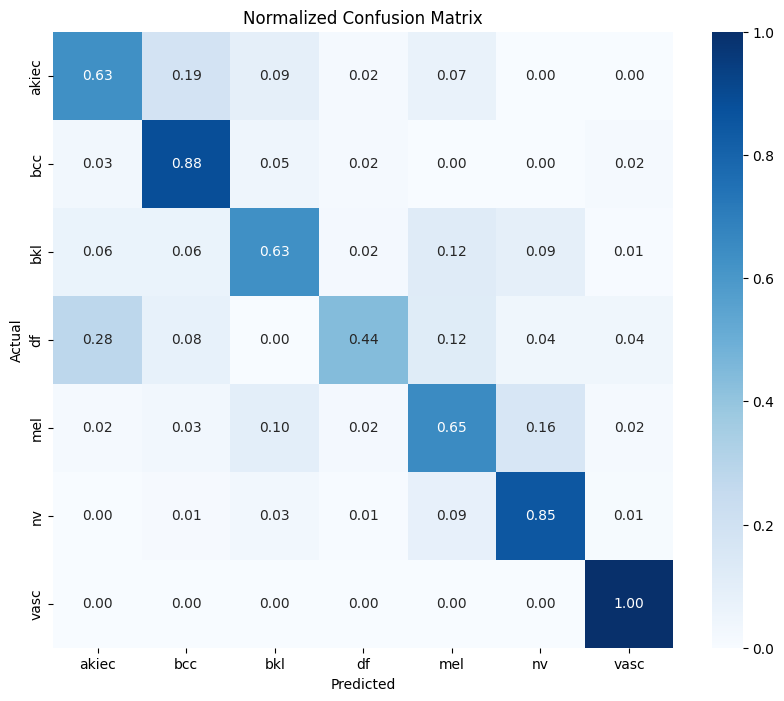

Confusion Matrix (normalized):
 [[6.29629630e-01 1.85185185e-01 9.25925926e-02 1.85185185e-02
  7.40740741e-02 0.00000000e+00 0.00000000e+00]
 [3.33333333e-02 8.83333333e-01 5.00000000e-02 1.66666667e-02
  0.00000000e+00 0.00000000e+00 1.66666667e-02]
 [6.45161290e-02 6.45161290e-02 6.29032258e-01 2.15053763e-02
  1.23655914e-01 9.13978495e-02 5.37634409e-03]
 [2.80000000e-01 8.00000000e-02 0.00000000e+00 4.40000000e-01
  1.20000000e-01 4.00000000e-02 4.00000000e-02]
 [1.65745856e-02 3.31491713e-02 9.94475138e-02 2.20994475e-02
  6.51933702e-01 1.60220994e-01 1.65745856e-02]
 [9.98003992e-04 1.39720559e-02 3.39321357e-02 5.98802395e-03
  8.58283433e-02 8.51297405e-01 7.98403194e-03]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 1.00000000e+00]]
Classification Report:
               precision    recall  f1-score   support

       akiec       0.58      0.63      0.60        54
         bcc       0.55      0.88      0.68        60
         b

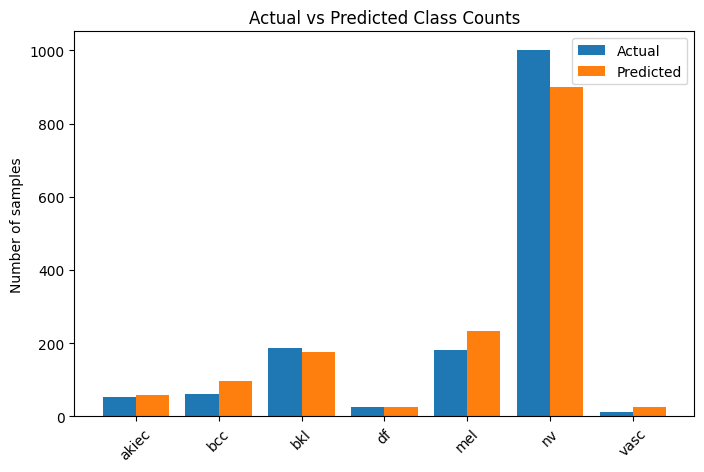

actual_counts: [  54   60  186   25  181 1002   11]
pred_counts: [ 59  97 177  27 234 900  25]


In [87]:
from utils import evaluate_model

model = MultiModalViT(meta_input_dim, num_classes).to(device)
model.load_state_dict(torch.load("checkpoints/best_multimodal_vit_V2.pth", map_location=device))

# Evaluate the model on the test set
all_labels, all_preds = evaluate_model(model, test_loader, device, le)

In this version (V2), we removed the class weights entirely. Interestingly, **the results were much better than expected**. Instead of becoming "lazy," the Vision Transformer used its high modeling capacity to achieve a great balance.

**Cancer Detection (The Dangerous Classes)**
- **Melanoma (mel)**: In our first experiments, the model was either missing almost everything or seeing cancer in every mole. In V2, we achieved a 0.65 Recall. This means the model is now catching 65% of Melanomas naturally. More importantly, the 0.50 Precision means that half of its "cancer alarms" are correct, which is a huge step forward in reducing patient anxiety.

- **Basal Cell Carcinoma (BCC)**: This cancer had an incredible 0.88 Recall. The ViT is exceptionally good at identifying this type of malignancy, even without extra weight.

**Success in Rare & Benign Classes**
- **Vascular (vasc) and Dermatofibroma (df)**: These were the big surprises. The model achieved a 1.00 Recall for Vascular and a very solid 0.42 F1-score for df. It proved it can detect rare lesions without being "forced" by weights.
- **Nevus (nv)**: With 85% Recall and 95% Precision, the model is now extremely reliable at telling a patient: "This is just a normal mole."
- **Benign Keratosis (bkl)**: With a 0.64 F1-score, the "Attention" mechanism is successfully spotting the textures that separate harmless spots from danger.

**The "Healthy" Balance**
By removing the weights, we allowed the model to see the "real world." In the real world, most spots are not cancer.
- **V1 was Paranoid**: It called everything cancer to be "safe," but it was wrong too often.
- **V2 is Wise**: It trusts its eyes. It identifies common moles correctly (High Accuracy) while still maintaining a strong watch for the dangerous Melanomas and BCCs.

Even though the results are great, we want to see if we can reach the "Perfect Balance." In V3, we will use **softened weights** to see if we can push the Melanoma Recall even higher without losing the amazing Precision we found in V2. We are moving from a "great model" to a "finely-tuned clinical tool."

In [ ]:
soft_weights = np.sqrt(weights)
class_weights_tensor_soft = torch.tensor(soft_weights, dtype=torch.float32)

print("Original Weights:", weights)
print("Softened Weights (sqrt):", soft_weights)

Original Weights: [ 4.6844956   2.51508542  1.3143997  13.0056391   1.33933411  0.2129775
  9.1521164 ]
Softened Weights (sqrt): [2.16436956 1.58590209 1.14647272 3.60633319 1.15729603 0.46149485
 3.0252465 ]


In [99]:
model = MultiModalViT(meta_input_dim, num_classes).to(device)

for param in model.vit.parameters():
    param.requires_grad = False
    
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(device))

In [100]:
model = train_model(
    model=model,
    train_loader=train_loader_multi_vit,
    val_loader=val_loader_multi_vit,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=200,
    patience=10,
    save_path="checkpoints/best_multimodal_vit_V3.pth"
)

Epoch 1/200 | Train Loss: 1.1592 Acc: 0.2888 | Val Loss: 3.4455 Acc: 0.0493
Epoch 2/200 | Train Loss: 0.7135 Acc: 0.4342 | Val Loss: 3.2887 Acc: 0.0908
Epoch 3/200 | Train Loss: 0.5781 Acc: 0.4850 | Val Loss: 2.7908 Acc: 0.1257
Epoch 4/200 | Train Loss: 0.4937 Acc: 0.5320 | Val Loss: 2.5668 Acc: 0.1441
Epoch 5/200 | Train Loss: 0.4434 Acc: 0.5579 | Val Loss: 2.4318 Acc: 0.1559
Epoch 6/200 | Train Loss: 0.3867 Acc: 0.5927 | Val Loss: 2.2561 Acc: 0.1618
Epoch 7/200 | Train Loss: 0.3809 Acc: 0.5949 | Val Loss: 2.1455 Acc: 0.2033
Epoch 8/200 | Train Loss: 0.3608 Acc: 0.6203 | Val Loss: 1.9900 Acc: 0.2546
Epoch 9/200 | Train Loss: 0.3321 Acc: 0.6416 | Val Loss: 2.0697 Acc: 0.2520
Epoch 10/200 | Train Loss: 0.3251 Acc: 0.6537 | Val Loss: 1.9549 Acc: 0.2882
Epoch 11/200 | Train Loss: 0.3061 Acc: 0.6669 | Val Loss: 1.9327 Acc: 0.3072
Epoch 12/200 | Train Loss: 0.2845 Acc: 0.6819 | Val Loss: 1.7730 Acc: 0.3625
Epoch 13/200 | Train Loss: 0.2872 Acc: 0.6891 | Val Loss: 1.7503 Acc: 0.3697
Epoch 14

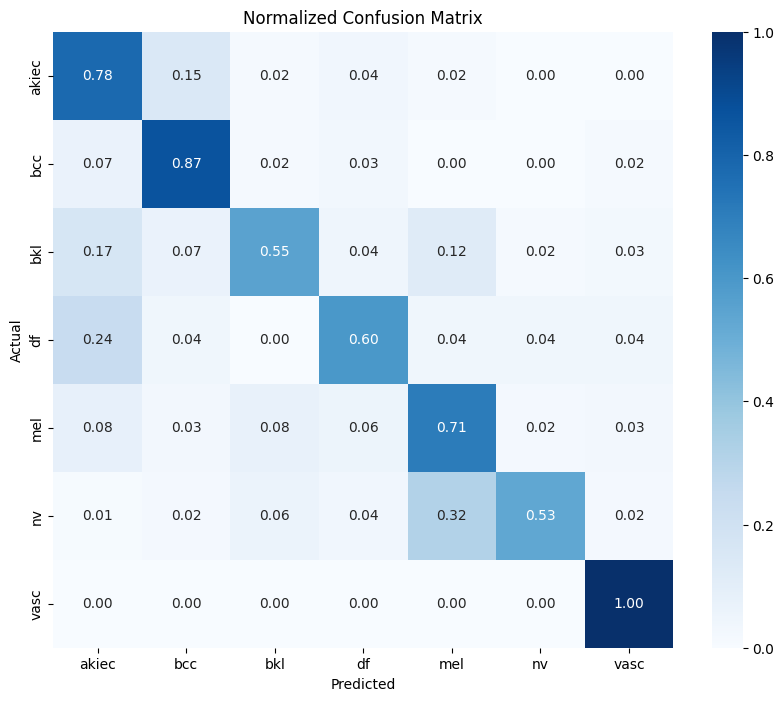

Confusion Matrix (normalized):
 [[0.77777778 0.14814815 0.01851852 0.03703704 0.01851852 0.
  0.        ]
 [0.06666667 0.86666667 0.01666667 0.03333333 0.         0.
  0.01666667]
 [0.16666667 0.06989247 0.55376344 0.04301075 0.12365591 0.01612903
  0.02688172]
 [0.24       0.04       0.         0.6        0.04       0.04
  0.04      ]
 [0.08287293 0.02762431 0.07734807 0.05524862 0.70718232 0.02209945
  0.02762431]
 [0.00898204 0.02295409 0.05888224 0.03892216 0.31636727 0.53293413
  0.02095808]
 [0.         0.         0.         0.         0.         0.
  1.        ]]
Classification Report:
               precision    recall  f1-score   support

       akiec       0.39      0.78      0.52        54
         bcc       0.51      0.87      0.64        60
         bkl       0.58      0.55      0.57       186
          df       0.20      0.60      0.30        25
         mel       0.27      0.71      0.39       181
          nv       0.99      0.53      0.69      1002
        vasc       0

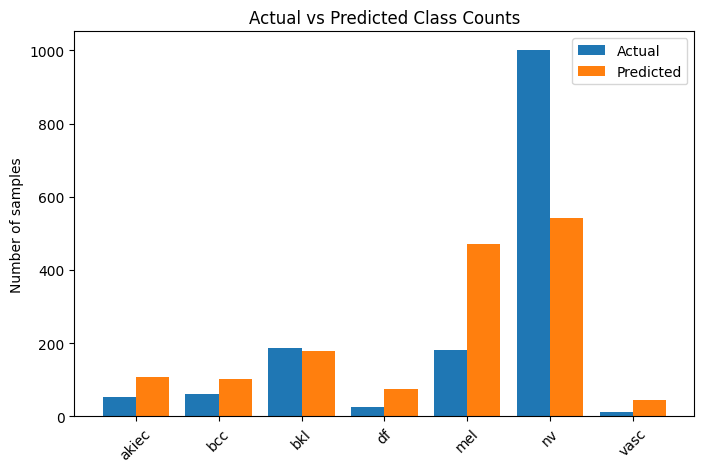

actual_counts: [  54   60  186   25  181 1002   11]
pred_counts: [107 102 178  76 470 542  44]


In [101]:
from utils import evaluate_model

model = MultiModalViT(meta_input_dim, num_classes).to(device)
model.load_state_dict(torch.load("checkpoints/best_multimodal_vit_V3.pth", map_location=device))

# Evaluate the model on the test set
all_labels, all_preds = evaluate_model(model, test_loader, device, le)

## Interpretation of Training Results

The plots above illustrate the training and validation performance of the **Augmented Multimodal Model**. By analyzing the behavior of the Accuracy and Loss curves, we can draw the following conclusions:

### 1. Accuracy Analysis: Stability and Generalization
* **The Learning Plateau:** Both training and validation accuracy converge rapidly and reach a plateau after approximately **Epoch 5**. This suggests that the model has reached its maximum learning capacity given the current dataset distribution. The accuracy remains stable at around **67%**.
* **Minimal Overfitting:** A key success of this phase is the narrow gap between the training (blue) and validation (orange) lines. This indicates excellent **generalization**. Thanks to the **Data Augmentation** strategy (flips, rotations, and color shifts), the model is not merely memorizing training samples but is learning robust features that apply equally well to unseen validation data.

### 2. Loss Analysis: Convergence and Optimization
* **Smooth Convergence:** The Loss curves show a steady, downward trend without significant oscillations. This confirms that the choice of the **Adam optimizer** and the learning rate are well-suited for this architecture, leading to a stable optimization process.
* **The Training/Validation Gap:** At several points, the validation loss is slightly lower than the training loss. This is a common phenomenon when using **Dropout** and **Data Augmentation**. Since these regularization techniques make the "training task" more difficult to prevent overfitting, but are disabled during validation, the model often finds the validation set "easier" to predict, resulting in superior performance metrics on the latter.

### 3. Strategic Conclusion: GANs
While the model is technically sound and shows no signs of overfitting, the **67% accuracy ceiling** indicates a bottleneck caused by **Class Imbalance**. The model has learned the features of the majority class (Melanocytic Nevi) effectively but lacks sufficient unique samples to distinguish minority classes. This justifies the transition to the next step , where we will use **Generative Adversarial Networks (GANs)** to synthesize new data and break through this performance plateau.

## DCGAN

In medical imaging datasets like HAM10000, class imbalance is a common challenge. Often, there are significantly fewer malignant samples (like Melanoma) compared to benign ones. To address this, we can use Generative AI to create synthetic data, acting as an advanced form of data augmentation.

For this task, we implemented a **Deep Convolutional Generative Adversarial Network (DCGAN)**. Unlike standard GANs that flatten images and lose spatial awareness, a DCGAN uses specialized convolutional layers to scan images in 2D grids. This allows the model to learn complex spatial features, such as the irregular borders, color gradients, and textures that define a melanoma.

The architecture consists of two competing neural networks:
* **The Generator:** Acts as the "forger." It takes a vector of random noise and uses `ConvTranspose2d` (upsampling) layers to gradually construct a 64x64 RGB image.
* **The Discriminator:** Acts as the "detective." It takes 64x64 images (both real from the dataset and fake from the generator) and uses `Conv2d` layers to determine if the image is authentic.

As they train against each other, the Generator becomes increasingly skilled at producing highly realistic synthetic lesions.

### Data Preparation and Model Execution

Before training the DCGAN, the data must be strictly formatted to match the network's mathematical requirements:
1. **Resizing:** The images are downscaled to `64x64` pixels, which is the exact spatial dimension our convolutional layers are mathematically designed to process.
2. **Augmentation:** We apply a random horizontal flip. This artificially expands our dataset, forcing the Discriminator to learn more robust features rather than memorizing the exact orientation of the training images.
3. **Normalization:** The Generator outputs images through a `Tanh` activation function, which produces values between `-1` and `1`. To make a fair comparison, we must normalize our real input images from the standard `[0, 1]` pixel range to the exact same `[-1, 1]` range.

With the data prepared, we initialize the models and begin the adversarial training loop.

In [ ]:
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset

print("Preparing Melanoma-only dataset for DCGAN...")

# 1. Filter the dataset to ONLY include Melanoma
# (In the HAM10000 dataset, Melanoma is labeled as 'mel' in the 'dx' column)
melanoma_df = train_df[train_df['dx'] == 'mel'].copy()
print(f"Total Melanoma images for GAN training: {len(melanoma_df)}")

# 2. Load and resize the images using your existing function
IMG_SIZE = (64, 64) # DCGAN strictly expects 64x64
X_melanoma_tensor = load_images(melanoma_df, IMG_SIZE)

# Ensure the tensor is in [0, 1] range (float32) before normalizing
if X_melanoma_tensor.max() > 1.0:
    X_melanoma_tensor = X_melanoma_tensor.float() / 255.0

# 3. Define specific GAN transformations
# DCGANs use Tanh() at the end of the Generator, which outputs pixels from -1 to 1.
# Therefore, we MUST normalize our real images to -1 to 1 as well!
gan_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5), # Augmentation to make the Discriminator smarter!
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) # Shifts pixels from [0,1] to [-1,1]
])

# Apply the transformations to our loaded tensor
X_melanoma_transformed = gan_transform(X_melanoma_tensor)

# 4. Create dummy labels (the GAN discriminator creates its own real/fake labels)
# 4 is the encoded index for 'mel'
y_melanoma_tensor = torch.full((len(melanoma_df),), 4, dtype=torch.long)

# 5. Create the Dataset and DataLoader
melanoma_dataset = TensorDataset(X_melanoma_transformed, y_melanoma_tensor)

# 128 is the standard optimal batch size for DCGANs
BATCH_SIZE = 128
train_loader = DataLoader(melanoma_dataset, batch_size=BATCH_SIZE, shuffle=True)

print("GAN Data Preparation Complete. train_loader is ready!")

In [ ]:
from models.gan import Generator, Discriminator
from utils import train_gan

# 1. Setup & Hyperparameters
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 100
image_channels = 3
num_epochs = 500

# Ensure it saves exactly where you want it
os.makedirs('checkpoints', exist_ok=True)
final_save_path = 'checkpoints/best_gan.pth'

# 2. Initialize Models
generator = Generator(latent_dim=latent_dim, image_channels=image_channels).to(device)
discriminator = Discriminator(image_channels=image_channels).to(device)

start_epoch = 0

# 3. Check for existing weights to avoid retraining
if os.path.exists(final_save_path):
    print(f"Loading finished pre-trained GAN models from {final_save_path}...")
    checkpoint = torch.load(final_save_path, map_location=device)
    generator.load_state_dict(checkpoint['generator_state_dict'])
    discriminator.load_state_dict(checkpoint['discriminator_state_dict'])
    start_epoch = num_epochs # Skips the training loop entirely
else:
    print("Training GAN from scratch on Melanoma images...")


In [ ]:
# 4. Train the Model
if start_epoch < num_epochs:
    generator, discriminator = train_gan(
        generator=generator,
        discriminator=discriminator,
        dataloader=train_loader, # Uses the loader from the previous cell
        num_epochs=num_epochs,
        device=device,
        save_path=final_save_path,
        latent_dim=latent_dim,
        start_epoch=start_epoch
    )

In [ ]:
# 5. Generate and View Results
generator.eval()
with torch.no_grad():
    # Create 16 random noise vectors
    noise = torch.randn(16, latent_dim, device=device)
    fake_images = generator(noise)

    # Display the grid
    plt.figure(figsize=(8,8))
    plt.axis("off")
    plt.title("Generated Melanoma Images")
    plt.imshow(np.transpose(vutils.make_grid(fake_images.to(device)[:16], padding=2, normalize=True).cpu(),(1,2,0)))
    plt.show()

### Results and Conclusion

The generated 64x64 images demonstrate that the DCGAN successfully learned the global morphological characteristics of melanomas.

**Key Observations:**
* **Color and Contrast:** The generator accurately mimics the dark brown and reddish pigmentation typical of melanomas, alongside the lighter contrast of the surrounding skin tone.
* **Shape and Structure:** The synthetic lesions exhibit the characteristic asymmetry and irregular borders that dermatologists look for when diagnosing malignant lesions.
* **Limitations:** Due to the `64x64` resolution limit of this specific architecture, the images lack ultra-fine dermatoscopic details (such as distinct skin pores, tiny blood vessels, or hair).

Overall, the model successfully captures the defining essence of the minority class. These synthetic images could theoretically be injected into a classification pipeline to help balance the dataset, potentially improving the robustness and generalizability of a diagnostic model.

In [ ]:
target_count = train_df['dx'].value_counts().max()
class_counts = train_df['dx'].value_counts()

# Esto te dirá exactamente cuántas imágenes sintéticas necesitas crear de cada una
missing_counts = target_count - class_counts
print(missing_counts)

## cDCGAN

In this section, we define our final architecture. While we initially used a standard DCGAN (Deep Convolutional GAN) as our baseline, we evolved the model into a Conditional GAN (cGAN) to meet the specific requirements of our medical imaging project.

### Set Up

First, we need to locate our data. As we saw, the HAM10000 dataset is splitted into two different folders (Part 1 and Part 2). By using os.path.join, we ensure the script can find every single image and the metadata file (the CSV) regardless of which operating system we are using.

In [ ]:
part1_path = os.path.join(path, "ham10000_images_part_1")
part2_path = os.path.join(path, "ham10000_images_part_2")
csv_file = os.path.join(path, "HAM10000_metadata.csv")

Before starting the training, we establish a configuration environment. We specifically set the image resolution to **128x128 to ensure full compatibility with our target CNN classifier**. This setup ensures that the training process is organized, monitorable, and produces data that is immediately ready for our data augmentation pipeline.

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 64
latent_dim = 100
num_epochs = 300
lr = 2e-4
img_size = 128
num_classes = 7

model_dir = 'checkpoints_cgan'
samples_dir = 'muestras_cgan'
os.makedirs(model_dir, exist_ok=True)
os.makedirs(samples_dir, exist_ok=True)

# Writer for TensorBoard
writer = SummaryWriter('runs/cgan_ham10000_v1')

As we did before, we need to handle the labels and file paths. Since the HAM10000 dataset comes with categorical names (like "*mel*" or "*nv*"), we convert them into numerical codes (*dx_idx*) that the model can understand. As the images are stored in two separate folders, we create a global **mapping** (*all_images*) to link every ID in the CSV file to its actual location on the disk.



In [ ]:
df = pd.read_csv(csv_file)
df['dx_idx'] = df['dx'].astype('category').cat.codes

# Create a mapping of image_id to file path for both parts of the dataset
all_images = {os.path.splitext(f)[0]: os.path.join(part1_path, f) for f in os.listdir(part1_path)}
all_images.update({os.path.splitext(f)[0]: os.path.join(part2_path, f) for f in os.listdir(part2_path)})


Now, we open each image and resize it to 128x128. As mentioned before, this is the standard resolution for our pipeline. We also normalize the pixel values from $[0, 255]$ to $[0, 1]$.

In [ ]:
def load_data(dataframe, img_map):
    imgs, labels = [], []
    print("Transforming images to tensors.")
    for _, row in dataframe.iterrows():
        img_path = img_map.get(row['image_id'])
        if img_path:
            img = Image.open(img_path).convert('RGB').resize((img_size, img_size))
            imgs.append(np.array(img))
            labels.append(row['dx_idx'])
    
    X = torch.tensor(np.array(imgs)).permute(0, 3, 1, 2).float() / 255.0
    y = torch.tensor(labels).long()
    return X, y

X_raw, y_raw = load_data(df, all_images)

Third, we apply **GAN-specific normalization**. We use *transforms.Normalize* to shift the pixel values from the $[0, 1]$ range to the $[-1, 1]$ range. This is a standard requirement for GANs because the Generator uses a Tanh activation function at its output, which produces values between $-1$ and $1$. Matching these ranges helps the model converge much faster.

In [ ]:
# Normalization for CNNs (from [0,1] to [-1,1])
gan_norm = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
X_norm = gan_norm(X_raw)

We wrap our tensors into a TensorDataset and a DataLoader. This allows us to feed the data into the model in shuffled batches of 64 images.

In [ ]:
dataset = TensorDataset(X_norm, y_raw)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

### Model Initialization, Loss, and Optimizer

We initialize the networks and their weights. We also apply *weights_init* (Mean 0, Std 0.02) because it prevents the gradients from exploding or vanishing at the very beginning of the training. It ensures the "competition" starts on level ground.

In [ ]:
from models.cgan import ConditionalGenerator, ConditionalDiscriminator

def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

G = ConditionalGenerator(num_classes=num_classes, latent_dim=latent_dim).to(device)
D = ConditionalDiscriminator(num_classes=num_classes).to(device)
G.apply(weights_init)
D.apply(weights_init)

We use the Adam optimizer for both networks, but we implement a strategy called **TTUR** (Two-Time Scale Update Rule):
 - *optimizerG* has a learning rate of 0.0002.
 - *optimizerD* has a slower learning rate of 0.00005.
By making the **Discriminator learn more slowly**, we prevent it from becoming "too powerful" too quickly, which allows the Generator enough time to learn how to create realistic skin textures.

In [ ]:
optimizerG = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizerD = torch.optim.Adam(D.parameters(), lr=0.00005, betas=(0.5, 0.999))
criterion = nn.BCEWithLogitsLoss()

We create a set of "fixed" random numbers and labels. During the whole training, we use these same numbers to see how the model's painting skills improve. It’s like asking the artist to paint the same picture every 10 minutes to see if they are getting better.

In [ ]:
# For TensorBoard: 8 images for each of the 7 classes
fixed_noise = torch.randn(56, latent_dim, device=device)
fixed_labels = torch.tensor([c for c in range(7) for _ in range(8)], device=device)

### Training

Now, using all this things, we are going to train the DCGAN.

In [ ]:
import utils
from utils import train_cgan
utils.train_cgan(
    G=G, 
    D=D, 
    train_loader=train_loader, 
    optimizerG=optimizerG, 
    optimizerD=optimizerD, 
    criterion=criterion, 
    device=device, 
    num_epochs=num_epochs, 
    latent_dim=latent_dim, 
    writer=writer, 
    samples_dir=samples_dir, 
    model_dir=model_dir, 
    fixed_noise=fixed_noise, 
    fixed_labels=fixed_labels
)


### Image Generation

We chose Hugging Face as our storage partner. To keep our GitHub repository clean and professional, we decided to host our model weights on Hugging Face.

In [ ]:
import importlib
import models.cgan  # Asegúrate de poner la ruta correcta a tu archivo
importlib.reload(models.cgan)

from models.cgan import ConditionalGenerator

# # --- HUGGING FACE CONFIGURATION ---
REPO_ID = "Gonzatorra/CGAN_HAM10000_V1"
FILENAME = "cgan_ham_128_epoch_150.pth"
LATENT_DIM = 100
NUM_CLASSES = 7

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load file from Hugging Face Hub
try:
    print(f" Dowloading weights from Hugging Face ({REPO_ID})...")
    model_path = hf_hub_download(repo_id=REPO_ID, filename=FILENAME)
    print(f"File downloaded to: {model_path}")
    
except Exception as e:
    print(f"Error at loading weights: {e}")

# # Initialize the Generator model
netG = ConditionalGenerator(num_classes=NUM_CLASSES, latent_dim=LATENT_DIM).to(device)

# Load the checkpoint from Hugging Face
checkpoint = torch.load(model_path, map_location=device)

Once the file is downloaded, we load it into our *ConditionalGenerator*.

In [ ]:
# Check if the checkpoint is a dictionary or just the state_dict
if isinstance(checkpoint, dict):
    if "G" in checkpoint:
        netG.load_state_dict(checkpoint["G"])
    elif "generator" in checkpoint:
        netG.load_state_dict(checkpoint["generator"])
    else:
        netG.load_state_dict(checkpoint)
else:
    netG.load_state_dict(checkpoint)

netG.eval()
print("Model prepared to generate synthetic images.")

The final step is to use our trained Generator to perform Data Augmentation. By synthesizing new images for the minority classes, we balance the dataset. This process ensures that our final classification model receives an equal amount of information for every disease type, significantly improving its ability to detect rare but critical conditions.

In [ ]:
import importlib
import utils  # import the module itself first

importlib.reload(utils)  # reload the module
from utils import balance_dataset_with_gan  # now import the updated function

utils.balance_dataset_with_gan(
    netG=netG,                      # Generator model
    X_orig=X_train_tensor,       # Original images tensor
    y_orig=y_train_tensor,       # Original labels tensor
    device=device,
    latent_dim=100
)

### Image Improvement

In [ ]:
optimizerG = torch.optim.Adam(G.parameters(), lr=0.00002, betas=(0.5, 0.999)) # 2e-5 (Muy lento)
optimizerD = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))  # 2e-4 (Normal)

In [ ]:
checkpoint_path = os.path.join(model_dir, 'cgan_ham_128_epoch_300.pth')

if os.path.exists(checkpoint_path):
    print(f"Cargando pesos desde {checkpoint_path}...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    G.load_state_dict(checkpoint['G'])
    D.load_state_dict(checkpoint['D'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Resumiendo desde la época {start_epoch}")
else:
    print("No se encontró checkpoint. Iniciando desde cero.")
    start_epoch = 0

In [ ]:
import importlib
import utils  # import the module itself first

importlib.reload(utils)  # reload the module
from utils import train_cgan_retrain  # now import the updated function


train_cgan_retrain(
    G, D, train_loader, 
    optimizerG, optimizerD, 
    nn.BCEWithLogitsLoss(), 
    device,
    num_epochs=500, 
    start_epoch=start_epoch, # Asegúrate de que start_epoch sea 300
    latent_dim=latent_dim, 
    writer=writer, 
    samples_dir=samples_dir, 
    model_dir=model_dir, 
    fixed_noise=fixed_noise, 
    fixed_labels=fixed_labels
)

### Simple CNN + CDGAN images

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from torchvision.datasets import ImageFolder
import torchvision.transforms as T
import importlib
import utils

# --- 1. DEFINICIÓN DE TRANSFORMACIONES ---

gan_transform = T.Compose([
    T.Resize((128, 128)),
    T.ToTensor(),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

train_transform_real = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(20),
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

val_transform_norm = T.Compose([
    T.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# --- 2. CREACIÓN DE DATASETS ---

# CAMBIO 1: Añadir target_transform para convertir el int de la carpeta en Tensor
gan_dataset = ImageFolder(
    root="gan_images",
    transform=gan_transform,
    target_transform=lambda y: torch.tensor(y, dtype=torch.long) # <--- Crucial
)

mapping = {name: i for i, name in enumerate(le.classes_)}
gan_dataset.class_to_idx = mapping

class ImageDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform
    def __len__(self):
        return len(self.labels)
    
    # CAMBIO 2: Asegurar que la etiqueta real también sea devuelta como Tensor Long
    def __getitem__(self, idx):
        img = self.images[idx]
        label = self.labels[idx]
        
        # Convertir a tensor si viene como valor simple de numpy o int
        if not isinstance(label, torch.Tensor):
            label = torch.tensor(label, dtype=torch.long)
        else:
            label = label.long() # Asegurar tipo Long para CrossEntropy
            
        if self.transform:
            img = self.transform(img)
        return img, label

# Dataset Real
real_train_dataset = ImageDataset(
    X_train_tensor, 
    y_train_tensor, 
    transform=train_transform_real
)

# --- 3. COMBINAR Y CREAR LOADERS ---

train_dataset_balanced = ConcatDataset([real_train_dataset, gan_dataset])
train_loader = DataLoader(train_dataset_balanced, batch_size=32, shuffle=True)

val_dataset_norm = ImageDataset(X_val_tensor, y_val_tensor, transform=val_transform_norm)
val_loader = DataLoader(val_dataset_norm, batch_size=32, shuffle=False)

print(f"✅ Dataset balanceado listo: {len(train_dataset_balanced)} imágenes totales.")

In [ ]:
from models.simple_cnn import SimpleCNN

# Inicializar modelo
model = SimpleCNN(input_channels=3, num_classes=7, dropout_rate=0.5).to(device)

# Al estar balanceado, ya no usamos 'weight' en el criterion
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# Entrenar con el nuevo set balanceado
from utils import train_model
trained_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    epochs=200,
    patience=15,
    save_path="checkpoints/best_simple_cnn_balanced.pth"
)

In [ ]:

# --- EVALUACIÓN FINAL ---

from utils import evaluate_model

# Cargar pesos del mejor modelo balanceado
simple_model = SimpleCNN(input_channels=3, num_classes=7, dropout_rate=0.5).to(device)
simple_model.load_state_dict(torch.load("checkpoints/best_simple_cnn_balanced.pth", map_location=device))

# DataLoader de test con normalización coincidente
test_dataset = ImageDataset(X_test_tensor, y_test_tensor, transform=val_transform_norm)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Evaluar y mostrar métricas
all_labels, all_preds = evaluate_model(simple_model, test_loader, device, le)